# QCNN for CIFAR-10 -- v3: CNN-Hybrid Features, Residual QCNN, 5000-Image Dataset

**Bachelor's Thesis Project -- Quantum Machine Learning**
Author: Mantavya

## Why v2 was still stuck near chance (best 19%, several *below* the 10% chance line)

v2 fixed the pooling-overshoot bug and the information bottleneck, and correctly diagnosed
that gradients were healthy. But two much bigger bottlenecks were left untouched:

1. **The classical front-end throws away almost all the signal before the quantum circuit
   ever sees it.** `StandardScaler -> PCA(8)` on **raw flattened pixels** (3072 numbers) keeps
   only 62% of variance, and worse, a *linear* projection of raw pixels cannot recover the
   spatial/textural structure (edges, shapes, textures) that separates CIFAR-10 classes --
   that's exactly the structure a *convolutional* feature extractor is designed to capture.
   No downstream circuit, quantum or classical, can recover information the PCA already
   discarded. This is almost certainly the dominant reason several encodings scored **below**
   chance (10%) -- garbage-in/garbage-out, not a quantum-circuit failure.
2. **Only 30 training images per class (300 total).** CIFAR-10 is a genuinely hard 10-class
   natural-image problem; 30 examples/class is far too few for *any* classifier (classical or
   quantum) to generalize, and it makes the PCA/LDA basis itself noisy and unstable across
   train/test splits.

Everything else in v2 (multi-basis readout, exact pooling schedule, batch broadcasting) was a
correct and useful fix, and is kept here. This version additionally:

- Replaces raw-pixel PCA with a **CNN feature extractor** (classical CV) trained on the same
  data, so the quantum circuit is fed features that already encode edges/shapes/textures
  instead of noisy linear pixel combinations -- this is the "hybrid CV + quantum" step.
- Adds **PCA -> LDA** on top of the CNN embedding (LDA is *supervised*, so it actively
  maximizes class separation in the reduced space -- unlike PCA, which is class-blind).
- Adds a **ResNet-style residual/skip connection adapted to the quantum circuit**, via
  data re-uploading: at every conv-pool layer, a scaled copy of the *original* encoded
  features is re-injected into the surviving wires (`y = F(x) + x`, quantum analogue), so
  deeper conv-pool stacks don't wash out the original signal the way plain feed-forward
  circuits do. A second, classical residual/skip concatenates a compressed slice of the CNN
  embedding directly onto the final classifier input, bypassing the quantum block entirely
  for a fraction of the features -- a literal ResNet shortcut around the "quantum block".
- Increases the dataset from 400 to **5000 images (500/class)**, sampled from CIFAR-10's
  full 60,000-image pool, with a proper train/val/test split.

## Practical note on cost

`default.qubit` full-state simulation cost grows exponentially with qubit count and roughly
linearly with samples x epochs. At 5000 images this benchmark is meaningfully heavier than
v2's 400-image run. Recommendations baked into this notebook:
- Use `lightning.qubit` (C++-backed) instead of `default.qubit` if installed -- same math,
  much faster; the notebook auto-detects and falls back gracefully.
- `N_ENCODINGS_TO_RUN` lets you benchmark only your top few encodings on the full 5000-image
  set (recommended), rather than all 10 -- run all 10 first on a smaller subsample to shortlist.
- This notebook was authored and syntax/logic-checked in a sandboxed environment without GPU/
  internet access to the CIFAR-10 mirror or PyPI's torch wheel, so it has **not** been executed
  end-to-end here. Run it in Colab (GPU runtime recommended for the CNN pretraining step) or
  locally where `torch`/`torchvision` and the CIFAR-10 download are available.


## 1. Setup

In [1]:
# If running on a fresh Colab / environment, uncomment the line below.
# !pip install pennylane pennylane-lightning scikit-learn joblib matplotlib torch torchvision -q


In [2]:
import os
import time
import warnings
from math import sqrt

import numpy as np
import matplotlib.pyplot as plt

import pennylane as qml
from pennylane import numpy as pnp

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from joblib import Parallel, delayed

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GOLDEN = (1 + sqrt(5)) / 2
print("PennyLane version:", qml.__version__)
print("Torch device:", DEVICE)

# Prefer the fast C++ simulator if it's installed; fall back to default.qubit otherwise.
try:
    qml.device("lightning.qubit", wires=2)
    QUANTUM_DEVICE_NAME = "lightning.qubit"
except Exception:
    QUANTUM_DEVICE_NAME = "default.qubit"
print("Quantum simulator backend:", QUANTUM_DEVICE_NAME)


PennyLane version: 0.44.1
Torch device: cuda
Quantum simulator backend: lightning.qubit


## 2. Global configuration

Key changes from v2:
- `SAMPLES_PER_CLASS: 40 -> 500` (5000 images total, drawn from CIFAR-10's full 60,000).
- New `CNN_*` block controls the classical feature extractor.
- `USE_LDA=True` adds a supervised LDA stage after PCA on the CNN embedding.
- `RESIDUAL_REUPLOAD_SCALE` controls the strength of the quantum skip connection (0 disables it,
  recovering the plain v2 QCNN block for comparison).
- `CLASSICAL_SKIP_DIM` controls how many raw CNN-embedding dimensions are concatenated directly
  onto the classifier input (the classical residual bypass around the quantum block). 0 disables it.


In [13]:
CONFIG = dict(
    SAMPLES_PER_CLASS   = 500,       # 500/class x 10 = 5000 images (from CIFAR-10's 60,000 total)
    NUM_CLASSES         = 10,
    TEST_SPLIT          = 0.20,
    VAL_SPLIT           = 0.10,      # carved out of the remaining train portion
    RANDOM_SEED         = SEED,

    # --- classical CV feature extractor (replaces raw-pixel PCA front-end) ---
    CNN_EPOCHS          = 40,        # was 15 -- early stopping (below) cuts this short automatically,
                                      # so raising the ceiling just lets the checkpointed model be better
    CNN_BATCH_SIZE      = 64,
    CNN_LR              = 1e-3,
    CNN_WEIGHT_DECAY    = 5e-4,      # NEW: L2 penalty on the CNN extractor -- it was overfitting
                                      # (train loss -> 0.24 while val acc plateaued/oscillated ~45-53%)
    CNN_EMBED_DIM       = 128,
    CNN_DROPOUT         = 0.3,       # NEW: dropout before the CNN's final FC layer
    USE_CNN_AUGMENTATION = True,     # NEW: random crop + horizontal flip during CNN training
    CNN_EARLY_STOP_PATIENCE = 6,     # NEW: stop the CNN once val acc hasn't improved in N epochs

    # --- dimensionality reduction on top of the CNN embedding ---
    DEFAULT_PCA_DIM     = 16,        # PCA on the 128-d CNN embedding (not raw pixels anymore)
    USE_LDA             = True,      # supervised LDA after PCA, big win for class separation
    LDA_DIM             = 8,         # <= NUM_CLASSES - 1 = 9; this is what actually feeds the qubits
    LDA_SHRINKAGE       = True,      # NEW: shrinkage LDA (Ledoit-Wolf) instead of vanilla SVD-LDA --
                                      # vanilla LDA on only 3600 samples / 10 classes finds a covariance
                                      # basis that trivially separates TRAIN (that's what it's optimized
                                      # to do) but doesn't generalize as well; shrinkage regularizes the
                                      # class-covariance estimate so the projection generalizes better.

    DEFAULT_N_QUBITS    = 8,         # register / chunk size (input qubits per QCNN register)
    QUBIT_SWEEP         = [2, 3, 4, 5, 6, 7, 8],

    N_OUT_QUBITS        = 4,         # qubits surviving after conv-pool
    CONV_DEPTH          = 2,
    FC_LAYERS           = 2,         # was 3 -- one fewer StronglyEntanglingLayers layer in the
                                      # quantum classifier head reduces trainable capacity relative
                                      # to only 3600 training samples
    SHARE_WEIGHTS_ACROSS_CHUNKS = True,
    USE_MULTI_BASIS_READOUT = True,

    # --- ResNet-style adaptations for the quantum circuit ---
    RESIDUAL_REUPLOAD_SCALE = 0.3,   # quantum skip connection strength (0 = disabled, = v2 behaviour)
    CLASSICAL_SKIP_DIM  = 8,         # classical CNN-embedding dims concatenated straight to the classifier

    EPOCHS              = 30,        # ceiling raised (was 15) -- with LR decay-on-plateau (below)
                                      # instead of a single fixed LR, training now has room to keep
                                      # making slow progress well past epoch 15 instead of being cut
                                      # off right as a decayed-LR phase starts paying off.
    BATCH_SIZE          = 64,
    LR                  = 0.02,      # v4 dropped this to 0.008 to kill the epoch-1-2 memorization
                                      # (train 85-96% instantly). That worked -- train/val gap is now
                                      # small and healthy -- but 0.008 combined with the L2 below turned
                                      # out to be too conservative: loss/accuracy went completely flat
                                      # after epoch ~2-3 and never moved again for the rest of training,
                                      # i.e. the optimizer stalled at a low-capacity equilibrium rather
                                      # than continuing to slowly improve. 0.02 (between the old 0.05
                                      # that overfit and the 0.008 that stalled) restores enough step
                                      # size to keep moving, and the LR_DECAY mechanism below (rather
                                      # than a single fixed value) is what actually prevents this from
                                      # sliding back into fast memorization.
    LR_DECAY_FACTOR     = 0.5,       # NEW: reduce-LR-on-plateau, Adam's stepsize is multiplied by this
                                      # once val hasn't improved for LR_DECAY_PATIENCE epochs, instead of
                                      # immediately early-stopping. This is what actually fixes "training
                                      # stops after 2 epochs": rather than giving up the moment progress
                                      # slows, the optimizer gets a smaller, more careful step size and
                                      # tries again -- exactly the tool for escaping a plateau instead of
                                      # sitting in it.
    LR_DECAY_PATIENCE   = 2,         # NEW: epochs with no val improvement before decaying LR
    L2_LAMBDA           = 0.006,     # was 0.02 -- that was strong enough (combined with the low LR) to
                                      # pin the linear head/FC-layer weights near their L2 equilibrium
                                      # almost immediately, leaving very little room for the CE loss
                                      # gradient to keep improving the fit. Lowered by ~3x.
    L2_LAMBDA_CIRCUIT   = 0.0005,    # was 0.002, lowered proportionally -- same reasoning for conv_w/pool_w.
    EARLY_STOP_PATIENCE = 8,         # was 4 -- now measured in epochs *after* LR has already been
                                      # decayed (typically 2-3 decay steps), so this is patience on top
                                      # of the plateau-recovery mechanism, not a replacement for it.
    QUANTUM_DEVICE      = QUANTUM_DEVICE_NAME,

    N_ENCODINGS_TO_RUN  = 3,          # was 10 -- run your top few first, do the full 10 as a final pass
    N_JOBS              = -1,

    # --- SPEED FIX ---
    # The circuit used to return qml.probs(...), which lightning.qubit's fast "adjoint"
    # differentiation cannot handle (adjoint only supports expval of Hermitian observables).
    # That silently forced PennyLane to fall back to parameter-shift: ~2 circuit evaluations
    # PER TRAINABLE PARAMETER, per batch, per epoch, per encoding -- this was the actual
    # 400-minutes bottleneck, not the 5000-image dataset size.
    # Fix: the circuit below now returns ONLY expvals (Z/X/Y per surviving qubit), so
    # lightning.qubit can use adjoint diff (1 forward + 1 backward pass total, regardless
    # of parameter count). default.qubit keeps using backprop, which was already fine.
    DIFF_METHOD         = "adjoint",  # used only when QUANTUM_DEVICE == "lightning.qubit"
)
np.random.seed(CONFIG["RANDOM_SEED"])
torch.manual_seed(CONFIG["RANDOM_SEED"])
CONFIG


{'SAMPLES_PER_CLASS': 500,
 'NUM_CLASSES': 10,
 'TEST_SPLIT': 0.2,
 'VAL_SPLIT': 0.1,
 'RANDOM_SEED': 42,
 'CNN_EPOCHS': 40,
 'CNN_BATCH_SIZE': 64,
 'CNN_LR': 0.001,
 'CNN_WEIGHT_DECAY': 0.0005,
 'CNN_EMBED_DIM': 128,
 'CNN_DROPOUT': 0.3,
 'USE_CNN_AUGMENTATION': True,
 'CNN_EARLY_STOP_PATIENCE': 6,
 'DEFAULT_PCA_DIM': 16,
 'USE_LDA': True,
 'LDA_DIM': 8,
 'LDA_SHRINKAGE': True,
 'DEFAULT_N_QUBITS': 8,
 'QUBIT_SWEEP': [2, 3, 4, 5, 6, 7, 8],
 'N_OUT_QUBITS': 4,
 'CONV_DEPTH': 2,
 'FC_LAYERS': 2,
 'SHARE_WEIGHTS_ACROSS_CHUNKS': True,
 'USE_MULTI_BASIS_READOUT': True,
 'RESIDUAL_REUPLOAD_SCALE': 0.3,
 'CLASSICAL_SKIP_DIM': 8,
 'EPOCHS': 30,
 'BATCH_SIZE': 64,
 'LR': 0.02,
 'LR_DECAY_FACTOR': 0.5,
 'LR_DECAY_PATIENCE': 2,
 'L2_LAMBDA': 0.006,
 'L2_LAMBDA_CIRCUIT': 0.0005,
 'EARLY_STOP_PATIENCE': 8,
 'QUANTUM_DEVICE': 'lightning.qubit',
 'N_ENCODINGS_TO_RUN': 3,
 'N_JOBS': -1,
 'DIFF_METHOD': 'adjoint'}

## 3. CIFAR-10 loading: 500 images/class (5000 total, up from 400)

Same balanced-sampling protocol as v2, just drawing from the full 60,000-image pool instead of
being capped at ~40/class. Falls back to a synthetic dataset if the download is unavailable
(e.g. no internet in a sandboxed environment) so the rest of the notebook can still be
smoke-tested end-to-end.


In [4]:
def load_cifar10_balanced(samples_per_class=500, num_classes=10, seed=42):
    rng = np.random.default_rng(seed)
    try:
        trainset = CIFAR10(root="./data", train=True, download=True)
        testset = CIFAR10(root="./data", train=False, download=True)
        X = np.concatenate([trainset.data, testset.data], axis=0)          # (60000, 32, 32, 3) uint8
        y = np.concatenate([np.array(trainset.targets), np.array(testset.targets)])
        source = "real CIFAR-10"
    except Exception as e:
        print(f"[WARNING] Failed to load CIFAR-10: {e}")
        print("Using synthetic dataset instead (for pipeline smoke-testing only).")
        X = rng.integers(0, 256, size=(num_classes * max(samples_per_class, 50), 32, 32, 3), dtype=np.uint8)
        y = np.repeat(np.arange(num_classes), max(samples_per_class, 50))
        source = "synthetic"

    X_bal, y_bal = [], []
    for cls in range(num_classes):
        idx = np.where(y == cls)[0]
        n_avail = len(idx)
        take = min(samples_per_class, n_avail)
        if take < samples_per_class:
            print(f"[note] class {cls}: only {n_avail} available, using {take}.")
        chosen = rng.choice(idx, size=take, replace=False)
        X_bal.append(X[chosen]); y_bal.append(y[chosen])

    X_bal = np.concatenate(X_bal).astype(np.uint8)
    y_bal = np.concatenate(y_bal).astype(np.int64)

    print("=" * 50)
    print(f"Source      : {source}")
    print(f"Total Images: {len(X_bal)}")
    print(f"Image shape : {X_bal.shape[1:]}")
    print("=" * 50)
    return X_bal, y_bal


CIFAR10_CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
                    "dog", "frog", "horse", "ship", "truck"]

X_images, y_all = load_cifar10_balanced(CONFIG["SAMPLES_PER_CLASS"], CONFIG["NUM_CLASSES"], CONFIG["RANDOM_SEED"])

# three-way split: train (for CNN + PCA/LDA + QCNN), val (early-stop/monitor), test (final report)
X_trainval_img, X_test_img, y_trainval, y_test = train_test_split(
    X_images, y_all, test_size=CONFIG["TEST_SPLIT"], stratify=y_all, random_state=CONFIG["RANDOM_SEED"])
X_train_img, X_val_img, y_train, y_val = train_test_split(
    X_trainval_img, y_trainval, test_size=CONFIG["VAL_SPLIT"], stratify=y_trainval, random_state=CONFIG["RANDOM_SEED"])

print("Train:", X_train_img.shape, " Val:", X_val_img.shape, " Test:", X_test_img.shape)


Files already downloaded and verified
Files already downloaded and verified
Source      : real CIFAR-10
Total Images: 5000
Image shape : (32, 32, 3)
Train: (3600, 32, 32, 3)  Val: (400, 32, 32, 3)  Test: (1000, 32, 32, 3)


## 4. Classical CV feature extractor -- the "hybrid" step

A small residual CNN (basic ResNet-style blocks: `Conv -> BN -> ReLU -> Conv -> BN` + identity
skip, added before the ReLU) is trained directly on the 5000-image subset as a classifier; the
128-d **penultimate layer** (post-global-average-pool, pre-final-linear) is then used as the
feature embedding fed onward to PCA/LDA. This is the actual "CV technique" doing the heavy
lifting that raw-pixel PCA never could: it learns edge/texture/shape detectors instead of
linear pixel combinations.

If you have internet access to torchvision's pretrained weights, an even stronger and faster
option is to swap this for a frozen `torchvision.models.resnet18(weights="IMAGENET1K_V1")`
truncated before its final FC layer -- see the commented alternative at the bottom of this cell.


In [14]:
class ResidualBlock(nn.Module):
    # Basic ResNet block: y = ReLU(F(x) + skip(x))
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.skip = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.skip(x)          # <-- the ResNet identity/projection shortcut
        return F.relu(out)


class SmallResNet(nn.Module):
    # NEW: dropout before the final FC layer (config["CNN_DROPOUT"]) -- the extractor was
    # overfitting on its own (train loss -> 0.24 while val acc oscillated ~45-53%), and that
    # noisy/overfit embedding is the ceiling everything downstream (PCA/LDA/QCNN) inherits.
    def __init__(self, num_classes=10, embed_dim=128, dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU())
        self.layer1 = ResidualBlock(32, 32, stride=1)
        self.layer2 = ResidualBlock(32, 64, stride=2)
        self.layer3 = ResidualBlock(64, embed_dim, stride=2)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x, return_embedding=False):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).flatten(1)       # (batch, embed_dim) -- this is the embedding we reuse
        if return_embedding:
            return x                      # embedding extraction always uses eval-mode (no dropout)
        return self.fc(self.dropout(x))


def to_tensor_batch(X_uint8):
    # (N, 32, 32, 3) uint8 -> normalized (N, 3, 32, 32) float tensor
    x = torch.from_numpy(X_uint8).float().permute(0, 3, 1, 2) / 255.0
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(1, 3, 1, 1)
    return (x - mean) / std


def augment_batch(xb):
    # NEW: light on-the-fly augmentation (random crop via padding + horizontal flip), applied only
    # during CNN training. This is standard practice for CIFAR-scale ResNets and is the single
    # biggest lever against the CNN extractor overfitting on only 3600 images -- it stops the
    # network from memorizing exact pixel arrangements.
    b, c, h, w = xb.shape
    pad = 4
    xp = F.pad(xb, (pad, pad, pad, pad), mode="reflect")
    out = torch.empty_like(xb)
    max_off = 2 * pad
    offs_h = torch.randint(0, max_off + 1, (b,))
    offs_w = torch.randint(0, max_off + 1, (b,))
    flip = torch.rand(b) < 0.5
    for i in range(b):
        crop = xp[i, :, offs_h[i]:offs_h[i] + h, offs_w[i]:offs_w[i] + w]
        out[i] = torch.flip(crop, dims=[2]) if flip[i] else crop
    return out


def train_cnn_extractor(X_train_img, y_train, X_val_img, y_val, config, device=DEVICE):
    model = SmallResNet(num_classes=config["NUM_CLASSES"], embed_dim=config["CNN_EMBED_DIM"],
                         dropout=config.get("CNN_DROPOUT", 0.0)).to(device)
    # NEW: weight_decay -- L2 regularization on the CNN's own weights (was 0 before).
    opt = torch.optim.Adam(model.parameters(), lr=config["CNN_LR"],
                            weight_decay=config.get("CNN_WEIGHT_DECAY", 0.0))
    Xtr = to_tensor_batch(X_train_img).to(device)
    ytr = torch.from_numpy(y_train).long().to(device)
    Xva = to_tensor_batch(X_val_img).to(device)
    yva = torch.from_numpy(y_val).long().to(device)

    use_aug = config.get("USE_CNN_AUGMENTATION", False)
    patience = config.get("CNN_EARLY_STOP_PATIENCE", 0)

    n = len(Xtr)
    best_val_acc, best_state, epochs_no_improve = -1.0, None, 0
    for epoch in range(config["CNN_EPOCHS"]):
        model.train()
        perm = torch.randperm(n)
        epoch_loss = 0.0
        for start in range(0, n, config["CNN_BATCH_SIZE"]):
            idx = perm[start:start + config["CNN_BATCH_SIZE"]]
            xb, yb = Xtr[idx], ytr[idx]
            if use_aug:
                xb = augment_batch(xb)
            opt.zero_grad()
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(idx)
        model.eval()
        with torch.no_grad():
            val_acc = (model(Xva).argmax(1) == yva).float().mean().item()

        # NEW: checkpoint the best-val state dict instead of always keeping the final epoch --
        # the old version just used whichever weights happened to exist after the last epoch,
        # even when (as observed) val acc had already peaked several epochs earlier and then
        # oscillated/decayed.
        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        marker = "  <-- best so far" if is_best else ""
        print(f"  [CNN extractor] epoch {epoch+1:2d}/{config['CNN_EPOCHS']} "
              f"loss={epoch_loss/n:.4f}  val_acc={val_acc:.3f}{marker}")

        if patience and epochs_no_improve >= patience:
            print(f"  [CNN extractor] early stopping (no val improvement in {patience} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"  [CNN extractor] restored best checkpoint: val_acc={best_val_acc:.3f}")
    return model


def extract_embeddings(model, X_img, device=DEVICE, batch_size=256):
    model.eval()
    outs = []
    with torch.no_grad():
        for start in range(0, len(X_img), batch_size):
            xb = to_tensor_batch(X_img[start:start + batch_size]).to(device)
            outs.append(model(xb, return_embedding=True).cpu().numpy())
    return np.concatenate(outs, axis=0)


cnn_model = train_cnn_extractor(X_train_img, y_train, X_val_img, y_val, CONFIG)
emb_train = extract_embeddings(cnn_model, X_train_img)
emb_val = extract_embeddings(cnn_model, X_val_img)
emb_test = extract_embeddings(cnn_model, X_test_img)
print("CNN embedding shapes:", emb_train.shape, emb_val.shape, emb_test.shape)

# --- Alternative (needs internet access to torchvision's pretrained weight mirror): ---
# from torchvision.models import resnet18, ResNet18_Weights
# backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
# backbone.fc = nn.Identity()   # -> 512-d embedding, frozen, no training needed


  [CNN extractor] epoch  1/40 loss=1.9652  val_acc=0.250  <-- best so far
  [CNN extractor] epoch  2/40 loss=1.7135  val_acc=0.367  <-- best so far
  [CNN extractor] epoch  3/40 loss=1.5745  val_acc=0.417  <-- best so far
  [CNN extractor] epoch  4/40 loss=1.4869  val_acc=0.422  <-- best so far
  [CNN extractor] epoch  5/40 loss=1.4158  val_acc=0.450  <-- best so far
  [CNN extractor] epoch  6/40 loss=1.3803  val_acc=0.487  <-- best so far
  [CNN extractor] epoch  7/40 loss=1.3347  val_acc=0.485
  [CNN extractor] epoch  8/40 loss=1.2755  val_acc=0.522  <-- best so far
  [CNN extractor] epoch  9/40 loss=1.2375  val_acc=0.492
  [CNN extractor] epoch 10/40 loss=1.2023  val_acc=0.455
  [CNN extractor] epoch 11/40 loss=1.1607  val_acc=0.530  <-- best so far
  [CNN extractor] epoch 12/40 loss=1.1517  val_acc=0.498
  [CNN extractor] epoch 13/40 loss=1.1111  val_acc=0.510
  [CNN extractor] epoch 14/40 loss=1.1164  val_acc=0.532  <-- best so far
  [CNN extractor] epoch 15/40 loss=1.0651  val_ac

## 5. Dimensionality reduction: PCA -> LDA on the CNN embedding (replaces raw-pixel PCA)

Two upgrades vs. v2:
1. The input to this stage is now the **128-d CNN embedding**, not 3072 raw pixels -- most of
   the useful variance is already concentrated here, so far less is thrown away per retained
   dimension.
2. An optional **LDA** stage after PCA is *supervised*: it chooses directions that maximize
   between-class separation rather than just variance, which directly targets what the
   classifier needs. `LDA_DIM` is capped at `NUM_CLASSES - 1` (a hard LDA limit).


In [15]:
def preprocess_hybrid(emb_train, emb_val, emb_test, y_train, config):
    ss = StandardScaler()
    Ztr = ss.fit_transform(emb_train)
    Zva = ss.transform(emb_val)
    Zte = ss.transform(emb_test)

    pca = PCA(n_components=config["DEFAULT_PCA_DIM"], random_state=config["RANDOM_SEED"])
    Ptr = pca.fit_transform(Ztr)
    Pva = pca.transform(Zva)
    Pte = pca.transform(Zte)
    explained = pca.explained_variance_ratio_.sum()

    final_dim = config["DEFAULT_PCA_DIM"]
    Ftr, Fva, Fte = Ptr, Pva, Pte
    if config["USE_LDA"]:
        lda_dim = min(config["LDA_DIM"], config["NUM_CLASSES"] - 1, config["DEFAULT_PCA_DIM"])
        # NEW: shrinkage LDA (Ledoit-Wolf, via solver="eigen") instead of vanilla SVD-LDA.
        # Vanilla LDA fits an unregularized class-covariance estimate from only ~3600 training
        # samples across 10 classes; that estimate is noisy, and because LDA explicitly optimizes
        # for train-set class separability, the noise gets baked into directions that separate
        # TRAIN particularly well without generalizing equally well to val/test. Shrinkage pulls
        # the covariance estimate toward a better-conditioned target, which is the standard fix
        # for LDA in the "few samples relative to classes/dimensions" regime.
        if config.get("LDA_SHRINKAGE", False):
            # NOTE: solver="lsqr" does NOT implement .transform() in sklearn (it's built for
            # classification only, not dimensionality reduction) -- raises NotImplementedError.
            # solver="eigen" supports both shrinkage AND .transform(), so use that instead.
            lda = LDA(n_components=lda_dim, solver="eigen", shrinkage="auto")
        else:
            lda = LDA(n_components=lda_dim)
        Ftr = lda.fit_transform(Ptr, y_train)
        Fva = lda.transform(Pva)
        Fte = lda.transform(Pte)
        final_dim = lda_dim

    mm = MinMaxScaler(feature_range=(0, np.pi))
    Xtr_f = mm.fit_transform(Ftr)
    Xva_f = mm.transform(Fva)
    Xte_f = mm.transform(Fte)
    return Xtr_f, Xva_f, Xte_f, explained, final_dim


X_train_k, X_val_k, X_test_k, explained_var, FEATURE_DIM = preprocess_hybrid(
    emb_train, emb_val, emb_test, y_train, CONFIG)

print(f"PCA({CONFIG['DEFAULT_PCA_DIM']}) on CNN embedding explains {explained_var:.3f} of variance")
print(f"Final feature dimension feeding the quantum circuit (after LDA={CONFIG['USE_LDA']}): {FEATURE_DIM}")
print("Feature range -> min:", X_train_k.min(), "max:", X_train_k.max())

y_train_onehot = np.eye(CONFIG["NUM_CLASSES"])[y_train]
y_val_onehot = np.eye(CONFIG["NUM_CLASSES"])[y_val]

# classical-skip features: a slice of the (standardized) CNN embedding, concatenated later
# directly onto the classifier input, bypassing the quantum block for these dimensions.
CLASSICAL_SKIP_DIM = min(CONFIG["CLASSICAL_SKIP_DIM"], emb_train.shape[1])
_skip_ss = StandardScaler().fit(emb_train[:, :CLASSICAL_SKIP_DIM])
skip_train = _skip_ss.transform(emb_train[:, :CLASSICAL_SKIP_DIM])
skip_val = _skip_ss.transform(emb_val[:, :CLASSICAL_SKIP_DIM])
skip_test = _skip_ss.transform(emb_test[:, :CLASSICAL_SKIP_DIM])


PCA(16) on CNN embedding explains 0.949 of variance
Final feature dimension feeding the quantum circuit (after LDA=True): 8
Feature range -> min: 0.0 max: 3.141592653589793


## 6. Patch / channel splitting (unchanged from v2 -- Quantum-Eyes patch processing)

In [16]:
def split_into_chunks(x, chunk_size):
    x = np.asarray(x, dtype=float)
    n = len(x)
    n_chunks = int(np.ceil(n / chunk_size))
    padded = np.zeros(n_chunks * chunk_size)
    padded[:n] = x
    return padded.reshape(n_chunks, chunk_size)


def split_matrix_into_chunks(X, chunk_size):
    return np.stack([split_into_chunks(row, chunk_size) for row in X], axis=0)


## 7. The 10 encodings (unchanged from v2)

Same corrected circuit definitions, ellipsis-indexed so each transparently supports batch
broadcasting.


In [19]:
def enc_pi4angle(x, wires):
    n = len(wires)
    xr = np.clip(np.asarray(x)[..., :n], 0, np.pi)
    for idx, w in enumerate(wires):
        qml.Hadamard(wires=w)
        qml.RY(2 * xr[..., idx], wires=w)


def enc_entangledangle(x, wires):
    n = len(wires)
    xr = np.clip(np.asarray(x)[..., :n], 0, np.pi)
    for w in wires:
        qml.Hadamard(wires=w)
    for idx, w in enumerate(wires):
        qml.RY(xr[..., idx], wires=w)
    for i in range(n - 1):
        qml.CNOT(wires=[wires[i], wires[i + 1]])


def enc_denseangle(x, wires):
    n = len(wires)
    xr = np.clip(np.asarray(x)[..., :n], 0, np.pi)
    for w in wires:
        qml.Hadamard(wires=w)
    for idx, w in enumerate(wires):
        qml.RZ(xr[..., idx] ** 2, wires=w)
    for i in range(n):
        for j in range(i + 1, min(i + 3, n)):
            wi, wj = wires[i], wires[j]
            qml.CNOT(wires=[wi, wj])
            qml.RZ(xr[..., i] * xr[..., j], wires=wj)
            qml.CNOT(wires=[wi, wj])


def enc_frqi(x, wires):
    n = len(wires)
    xr = np.clip(np.asarray(x)[..., :n], 0, np.pi)
    for w in wires:
        qml.Hadamard(wires=w)
    for idx, w in enumerate(wires):
        w_next = wires[(idx + 1) % n]
        qml.CRY(2 * xr[..., idx], wires=[w, w_next])


def enc_iqp(x, wires):
    n = len(wires)
    xr = np.clip(np.asarray(x)[..., :n], 0, np.pi)

    def layer():
        for w in wires:
            qml.Hadamard(wires=w)
        for idx, w in enumerate(wires):
            qml.RZ(xr[..., idx], wires=w)
        for i in range(n):
            for j in range(i + 1, n):
                wi, wj = wires[i], wires[j]
                qml.CNOT(wires=[wi, wj])
                qml.RZ(xr[..., i] * xr[..., j], wires=wj)
                qml.CNOT(wires=[wi, wj])

    layer()
    layer()


def enc_qhe(x, wires):
    n = len(wires)
    x2pi = np.clip(np.asarray(x)[..., :n], 0, np.pi) * 2.0
    for w in wires:
        qml.Hadamard(wires=w)
    for idx, w in enumerate(wires):
        qml.PhaseShift(x2pi[..., idx] % (2 * np.pi), wires=w)
    qml.adjoint(qml.QFT)(wires=wires)


def enc_hamiltonian(x, wires, t=1.0, steps=2):
    n = len(wires)
    xr = np.clip(np.asarray(x)[..., :n], 0, np.pi)
    for w in wires:
        qml.Hadamard(wires=w)
    dt = t / steps
    for _ in range(steps):
        for idx, w in enumerate(wires):
            qml.RZ(2 * dt * xr[..., idx], wires=w)
        for i in range(n):
            for j in range(i + 1, n):
                wi, wj = wires[i], wires[j]
                qml.CNOT(wires=[wi, wj])
                qml.RX(2 * dt * xr[..., i] * xr[..., j], wires=wj)
                qml.CNOT(wires=[wi, wj])


def enc_loghelix(x, wires, beta=3.0):
    n = len(wires)
    x2pi = np.clip(np.asarray(x)[..., :n], 0, np.pi) * 2.0
    for w in wires:
        qml.Hadamard(wires=w)
    for idx, w in enumerate(wires):
        phi = 2 * np.pi * np.log1p(beta * x2pi[..., idx] / (2 * np.pi)) / np.log1p(beta)
        qml.PhaseShift(phi % (2 * np.pi), wires=w)
    qml.adjoint(qml.QFT)(wires=wires)


def enc_fibspiral(x, wires):
    n = len(wires)
    x2pi = np.clip(np.asarray(x)[..., :n], 0, np.pi) * 2.0
    phi_gold = 2 * np.pi * (1 - 1 / GOLDEN)
    for idx, w in enumerate(wires):
        theta = np.arccos(np.clip(1 - x2pi[..., idx] / np.pi, -1.0, 1.0))
        phi = (phi_gold * (idx + 1) + x2pi[..., idx] / (2 * np.pi)) % (2 * np.pi)
        qml.RY(theta, wires=w)
        qml.PhaseShift(phi, wires=w)
    qml.adjoint(qml.QFT)(wires=wires)


def enc_dualenc(x, wires):
    n = len(wires)
    xr = np.clip(np.asarray(x)[..., :n], 0, np.pi)
    x2pi = xr * 2.0
    for idx, w in enumerate(wires):
        qml.RY(xr[..., idx], wires=w)
        phi = 2 * np.pi * np.log1p(x2pi[..., idx]) / np.log1p(2 * np.pi)
        qml.PhaseShift(phi % (2 * np.pi), wires=w)
    qml.adjoint(qml.QFT)(wires=wires)


ENCODINGS = {
    "AQHE-FibSpiral":  enc_fibspiral,
    "AQHE-DualEnc":    enc_dualenc,
    "Hamiltonian":     enc_hamiltonian,
    "IQP":             enc_iqp,
    "QHE":             enc_qhe,
    "AQHE-LogHelix":   enc_loghelix,
    "DenseAngle":      enc_denseangle,
    "EntangledAngle":  enc_entangledangle,
    "Pi4Angle":        enc_pi4angle,
    "FRQI":            enc_frqi,
}
print("Loaded", len(ENCODINGS), "embedding layers:", list(ENCODINGS.keys()))


Loaded 10 embedding layers: ['AQHE-FibSpiral', 'AQHE-DualEnc', 'Hamiltonian', 'IQP', 'QHE', 'AQHE-LogHelix', 'DenseAngle', 'EntangledAngle', 'Pi4Angle', 'FRQI']


## 8. QCNN building blocks + **ResNet-style residual/skip connection**

`conv_block` and `pool_block` are unchanged (Cong-Choi-Lukin conv, Roseler et al. pooling).

**New**: `qcnn_stack` now takes a `reupload_scale` parameter. At the *start of every conv-pool
layer*, a scaled copy of the original encoded input is re-uploaded (extra `RY` rotations) onto
the wires still in play, before that layer's convolution runs. This is the closest quantum-circuit
analogue of a ResNet identity shortcut `y = F(x) + x`: it stops later layers from being unable to
"see" the original signal after several rounds of pooling have compressed and mixed it away, the
same problem residual connections solve for deep classical nets. Setting
`RESIDUAL_REUPLOAD_SCALE=0` in `CONFIG` recovers exactly the v2 architecture, so you can A/B it.


In [20]:
CONV_PARAMS = 9   # 2 x U3 (3 params each) + 1 x CRot (3 params)
POOL_PARAMS = 2   # CRX angle, CRZ angle


def conv_block(theta, a, b):
    qml.U3(theta[0], theta[1], theta[2], wires=a)
    qml.U3(theta[3], theta[4], theta[5], wires=b)
    qml.CRot(theta[6], theta[7], theta[8], wires=[a, b])


def pool_block(theta, c, t):
    qml.CRZ(theta[1], wires=[c, t])
    qml.PauliX(wires=c)
    qml.CRX(theta[0], wires=[c, t])
    qml.PauliX(wires=c)


def n_conv_pool_layers(n0, n_out):
    layers, n = 0, n0
    while n > n_out:
        remove = n - n_out
        pairs = min(remove, n // 2)
        n -= pairs
        layers += 1
    return layers


def qcnn_stack(x, wires, conv_weights, pool_weights, n_out, depth_per_layer=1, reupload_scale=0.0):
    # conv-pool-... recursion, exact-landing (v2 fix retained), plus an optional
    # ResNet-style residual shortcut via data re-uploading (reupload_scale > 0).
    current = list(wires)
    n_in = len(wires)
    x_arr = np.asarray(x)
    layer = 0
    while len(current) > n_out:
        n = len(current)
        remove = n - n_out
        pairs = min(remove, n // 2)

        if reupload_scale > 0:
            # --- residual / skip connection: re-inject the ORIGINAL input signal ---
            for i, w in enumerate(current):
                src_idx = i % n_in
                qml.RY(reupload_scale * x_arr[..., src_idx], wires=w)

        for d in range(depth_per_layer):
            cp = conv_weights[layer][d]
            for i in range(n):
                conv_block(cp, current[i], current[(i + 1) % n])

        pp = pool_weights[layer]
        new_current = []
        for i in range(pairs):
            c, t = current[2 * i], current[2 * i + 1]
            pool_block(pp, c, t)
            new_current.append(t)
        new_current.extend(current[2 * pairs:])
        current = new_current
        layer += 1
    return current


## 9. The full hybrid multi-register QCNN model

Same per-register `n_out` clamping and multi-basis readout (probs + &lt;X&gt; + &lt;Y&gt;) as
v2. **New**: the classifier input now concatenates the quantum-circuit features with the
`CLASSICAL_SKIP_DIM`-wide classical CNN-embedding slice from Sec. 5 -- the classical residual
shortcut around the quantum block. Set `CLASSICAL_SKIP_DIM=0` to disable and isolate the
quantum-only contribution.


In [22]:
def build_qcnn_circuit(encoding_fn, n_qubits, n_out, fc_layers, multi_basis, reupload_scale):
    wires = list(range(n_qubits))
    dev = qml.device(CONFIG["QUANTUM_DEVICE"], wires=n_qubits)

    # SPEED FIX: only expvals are returned now (no qml.probs), so lightning.qubit can use
    # adjoint differentiation. This is functionally still a "multi-basis readout" -- Z, X, Y
    # expectation values per surviving qubit -- just without the probs vector that was
    # forcing the slow parameter-shift fallback.
    diff_method = CONFIG.get("DIFF_METHOD", "adjoint") if CONFIG["QUANTUM_DEVICE"] == "lightning.qubit" else "backprop"

    @qml.qnode(dev, diff_method=diff_method)
    def circuit(x, conv_w, pool_w, fc_w):
        encoding_fn(x, wires)
        remaining = qcnn_stack(x, wires, conv_w, pool_w, n_out,
                                depth_per_layer=CONFIG["CONV_DEPTH"], reupload_scale=reupload_scale)
        qml.StronglyEntanglingLayers(fc_w, wires=remaining)
        outs = [qml.expval(qml.PauliZ(w)) for w in remaining]
        if multi_basis:
            outs += [qml.expval(qml.PauliX(w)) for w in remaining]
            outs += [qml.expval(qml.PauliY(w)) for w in remaining]
        return tuple(outs)

    feat_dim = n_out * (3 if multi_basis else 1)
    return circuit, wires, feat_dim

def assemble_features(raw_out, multi_basis, n_out, is_batched):
    # raw_out is always a tuple of expvals now -- just stack them into a feature vector.
    return pnp.stack(raw_out, axis=-1) if is_batched else pnp.stack(raw_out)


def init_qcnn_weights(n_qubits, n_out, fc_layers, seed=0):
    rng = np.random.default_rng(seed)
    n_layers = n_conv_pool_layers(n_qubits, n_out)
    conv_w = pnp.array(0.1 * rng.standard_normal((max(n_layers, 1), CONFIG["CONV_DEPTH"], CONV_PARAMS)),
                        requires_grad=True)
    pool_w = pnp.array(0.1 * rng.standard_normal((max(n_layers, 1), POOL_PARAMS)), requires_grad=True)
    fc_shape = qml.StronglyEntanglingLayers.shape(n_layers=fc_layers, n_wires=n_out)
    # NEW: was 0.01 -- initializing this close to the identity meant the quantum FC/entangling
    # layer started with very little influence on the output and correspondingly tiny initial
    # gradients, so it barely moved during training and contributed little beyond whatever the
    # conv/pool stage + classical skip connection already provided. 0.05 gives it enough initial
    # spread to actually participate in learning without being as large/unstable as conv_w/pool_w.
    fc_w = pnp.array(0.05 * rng.standard_normal(fc_shape), requires_grad=True)
    return conv_w, pool_w, fc_w


def softmax_cross_entropy_batch(logits, y_onehot):
    m = pnp.max(logits, axis=1, keepdims=True)
    ex = pnp.exp(logits - m)
    p = ex / pnp.sum(ex, axis=1, keepdims=True)
    return -pnp.mean(pnp.sum(y_onehot * pnp.log(p + 1e-9), axis=1))


class HybridQCNN:
    def __init__(self, encoding_name, n_qubits, pca_dim, classical_skip_dim, seed=42):
        self.encoding_name = encoding_name
        self.encoding_fn = ENCODINGS[encoding_name]
        self.n_qubits = n_qubits
        self.n_out = min(CONFIG["N_OUT_QUBITS"], n_qubits)
        self.fc_layers = CONFIG["FC_LAYERS"]
        self.multi_basis = CONFIG["USE_MULTI_BASIS_READOUT"]
        self.n_chunks = int(np.ceil(pca_dim / n_qubits))
        self.share_weights = CONFIG["SHARE_WEIGHTS_ACROSS_CHUNKS"]
        self.classical_skip_dim = classical_skip_dim

        self.circuit, self.wires, self.feat_dim_per_chunk = build_qcnn_circuit(
            self.encoding_fn, n_qubits, self.n_out, self.fc_layers, self.multi_basis,
            CONFIG["RESIDUAL_REUPLOAD_SCALE"])

        rng = np.random.default_rng(seed)
        n_filters = 1 if self.share_weights else self.n_chunks
        self.conv_w, self.pool_w, self.fc_w = [], [], []
        for f in range(n_filters):
            cw, pw, fw = init_qcnn_weights(n_qubits, self.n_out, self.fc_layers, seed=seed + f)
            self.conv_w.append(cw); self.pool_w.append(pw); self.fc_w.append(fw)

        feat_dim = self.n_chunks * self.feat_dim_per_chunk + self.classical_skip_dim
        self.W = pnp.array(0.1 * rng.standard_normal((feat_dim, CONFIG["NUM_CLASSES"])), requires_grad=True)
        self.b = pnp.array(np.zeros(CONFIG["NUM_CLASSES"]), requires_grad=True)

    def _filter_idx(self, chunk_idx):
        return 0 if self.share_weights else chunk_idx

    def all_params(self):
        return (*self.conv_w, *self.pool_w, *self.fc_w, self.W, self.b)

    def set_params(self, flat):
        nF = len(self.conv_w)
        self.conv_w = list(flat[0:nF])
        self.pool_w = list(flat[nF:2 * nF])
        self.fc_w = list(flat[2 * nF:3 * nF])
        self.W, self.b = flat[3 * nF], flat[3 * nF + 1]

    def forward_batch(self, X_chunks_batch, skip_batch, conv_w, pool_w, fc_w, W, b):
        feats = []
        for c in range(self.n_chunks):
            fidx = self._filter_idx(c)
            xc = X_chunks_batch[:, c, :]
            raw = self.circuit(xc, conv_w[fidx], pool_w[fidx], fc_w[fidx])
            feats.append(assemble_features(raw, self.multi_basis, self.n_out, is_batched=True))
        if self.classical_skip_dim > 0:
            feats.append(pnp.array(skip_batch))     # <-- classical residual shortcut concatenated in
        feats = pnp.concatenate(feats, axis=1)
        return feats @ W + b

    def predict_proba_numpy(self, X_chunks_batch, skip_batch, batch_size=64):
        outs = []
        for start in range(0, len(X_chunks_batch), batch_size):
            xb = X_chunks_batch[start:start + batch_size]
            sb = skip_batch[start:start + batch_size]
            feats = []
            for c in range(self.n_chunks):
                fidx = self._filter_idx(c)
                raw = self.circuit(xb[:, c, :], self.conv_w[fidx], self.pool_w[fidx], self.fc_w[fidx])
                feats.append(np.array(assemble_features(raw, self.multi_basis, self.n_out, True)))
            if self.classical_skip_dim > 0:
                feats.append(sb)
            feats = np.concatenate(feats, axis=1)
            logits = feats @ np.array(self.W) + np.array(self.b)
            ex = np.exp(logits - logits.max(axis=1, keepdims=True))
            outs.append(ex / ex.sum(axis=1, keepdims=True))
        return np.concatenate(outs, axis=0)

    def predict(self, X_chunks_batch, skip_batch, batch_size=64):
        return np.argmax(self.predict_proba_numpy(X_chunks_batch, skip_batch, batch_size), axis=1)


## 10. Vectorized training loop (unchanged pattern, now also threads the classical skip features through)

In [23]:
# NOTE: relies on the global `y_train` (integer labels) defined in Sec. 3 for the
# per-epoch training-accuracy readout below.
def train_hybrid_qcnn(model, X_train_chunks, skip_train, y_train_onehot,
                       X_val_chunks, skip_val, y_val,
                       epochs, batch_size, lr, verbose=True,
                       l2_lambda=0.006, l2_lambda_circuit=0.0005, patience=8,
                       lr_decay_factor=0.5, lr_decay_patience=2):
    opt = qml.AdamOptimizer(stepsize=lr)
    n = len(X_train_chunks)
    rng = np.random.default_rng(0)

    def cost(*flat_params, Xb, Sb, Yb):
        nF = len(model.conv_w)
        conv_w, pool_w, fc_w = flat_params[0:nF], flat_params[nF:2 * nF], flat_params[2 * nF:3 * nF]
        W, b = flat_params[3 * nF], flat_params[3 * nF + 1]
        logits = model.forward_batch(Xb, Sb, conv_w, pool_w, fc_w, W, b)
        ce_loss = softmax_cross_entropy_batch(logits, Yb)

        l2 = pnp.sum(W ** 2) + pnp.sum(b ** 2)
        for fw in fc_w:
            l2 = l2 + pnp.sum(fw ** 2)
        l2_circuit = 0.0
        for cw in conv_w:
            l2_circuit = l2_circuit + pnp.sum(cw ** 2)
        for pw in pool_w:
            l2_circuit = l2_circuit + pnp.sum(pw ** 2)

        return ce_loss + l2_lambda * l2 + l2_lambda_circuit * l2_circuit

    params = list(model.all_params())
    history = {"epoch": [], "train_loss": [], "train_acc": [], "val_acc": [], "lr": [], "best_val_acc": None}

    best_val_acc = -1.0
    best_params = None
    epochs_no_improve = 0        # counts since last val improvement -- drives LR decay
    epochs_since_decay = 0       # counts since last LR cut -- drives early stopping
    n_decays = 0

    for epoch in range(epochs):
        perm = rng.permutation(n)
        epoch_loss, n_batches = 0.0, 0
        train_correct, train_seen = 0, 0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            Xb, Sb, Yb = X_train_chunks[idx], skip_train[idx], y_train_onehot[idx]
            new_params = opt.step(lambda *p: cost(*p, Xb=Xb, Sb=Sb, Yb=Yb), *params)
            params = list(new_params)
            batch_loss = float(cost(*params, Xb=Xb, Sb=Sb, Yb=Yb))
            epoch_loss += batch_loss
            n_batches += 1

            nF = len(model.conv_w)
            conv_w, pool_w, fc_w = params[0:nF], params[nF:2 * nF], params[2 * nF:3 * nF]
            W, b = params[3 * nF], params[3 * nF + 1]
            logits = model.forward_batch(Xb, Sb, conv_w, pool_w, fc_w, W, b)
            preds = np.argmax(np.array(logits), axis=1)
            train_correct += int((preds == y_train[idx]).sum())
            train_seen += len(idx)

        model.set_params(params)
        train_acc = train_correct / max(train_seen, 1)
        val_acc = accuracy_score(y_val, model.predict(X_val_chunks, skip_val))
        history["epoch"].append(epoch)
        history["train_loss"].append(epoch_loss / max(n_batches, 1))
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(opt.stepsize)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_params = [np.array(p) if not isinstance(p, np.ndarray) else p.copy()
                            for p in params]
            epochs_no_improve = 0
            epochs_since_decay = 0
        else:
            epochs_no_improve += 1
            epochs_since_decay += 1

        if verbose:
            marker = "  <-- best so far" if is_best else ""
            print(f"    epoch {epoch + 1:2d}/{epochs} | lr={opt.stepsize:.4f} | "
                  f"loss={history['train_loss'][-1]:.4f} "
                  f"| train acc={train_acc:.3f} | val acc={val_acc:.3f}{marker}")

        # NEW: reduce-LR-on-plateau, checked BEFORE the early-stopping check. This is the
        # actual fix for "training stops improving after 2 epochs and never moves again":
        # v4 went straight from "no improvement" to "give up" (early stopping only). Now,
        # the first few plateaus just shrink the step size and keep going -- often enough
        # on its own to escape a shallow local minimum -- and only after LR has already
        # been cut a couple of times AND it's still not improving does training actually stop.
        if lr_decay_factor and epochs_no_improve >= lr_decay_patience:
            opt.stepsize *= lr_decay_factor
            n_decays += 1
            epochs_no_improve = 0
            if verbose:
                print(f"    no improvement for {lr_decay_patience} epochs -- "
                      f"decaying lr to {opt.stepsize:.4f} (decay #{n_decays})")

        # Early stopping is now measured in epochs since the last LR decay, not epochs
        # since the last val improvement -- so a run only stops once it's had a genuine
        # chance to recover at a smaller step size and still failed to.
        if patience and epochs_since_decay >= patience:
            if verbose:
                print(f"    early stopping (no val improvement in {patience} epochs "
                      f"even after {n_decays} lr decay(s))")
            break

    if best_params is not None:
        model.set_params(best_params)
    history["best_val_acc"] = best_val_acc
    return history


## 11. Main benchmark

Runs `N_ENCODINGS_TO_RUN` encodings (sorted by v2's prior ranking, best first) on the full
5000-image dataset, in parallel via joblib. Report the held-out **test** accuracy (never used for
model selection) at the end.


In [24]:
X_train_chunks = split_matrix_into_chunks(X_train_k, CONFIG["DEFAULT_N_QUBITS"])
X_val_chunks = split_matrix_into_chunks(X_val_k, CONFIG["DEFAULT_N_QUBITS"])
X_test_chunks = split_matrix_into_chunks(X_test_k, CONFIG["DEFAULT_N_QUBITS"])

PRIORITY_ORDER = ["AQHE-DualEnc", "FRQI", "IQP", "Pi4Angle", "AQHE-LogHelix",
                   "EntangledAngle", "Hamiltonian", "QHE", "DenseAngle", "AQHE-FibSpiral"]
encodings_to_run = PRIORITY_ORDER[:CONFIG["N_ENCODINGS_TO_RUN"]]
print("Running:", encodings_to_run)


def run_one_encoding(name):
    print(f"  -> training {name} ...")
    t_enc = time.time()
    model = HybridQCNN(name, CONFIG["DEFAULT_N_QUBITS"], FEATURE_DIM, CLASSICAL_SKIP_DIM,
                        seed=CONFIG["RANDOM_SEED"])
    history = train_hybrid_qcnn(model, X_train_chunks, skip_train, y_train_onehot,
                                 X_val_chunks, skip_val, y_val,
                                 epochs=CONFIG["EPOCHS"], batch_size=CONFIG["BATCH_SIZE"],
                                 lr=CONFIG["LR"], verbose=True,
                                 l2_lambda=CONFIG["L2_LAMBDA"],
                                 l2_lambda_circuit=CONFIG["L2_LAMBDA_CIRCUIT"],
                                 patience=CONFIG["EARLY_STOP_PATIENCE"],
                                 lr_decay_factor=CONFIG["LR_DECAY_FACTOR"],
                                 lr_decay_patience=CONFIG["LR_DECAY_PATIENCE"])
    test_acc = accuracy_score(y_test, model.predict(X_test_chunks, skip_test))
    print(f"     {name}: test acc = {test_acc:.3f}  ({time.time() - t_enc:.1f}s)")
    return name, test_acc, history


t0 = time.time()
results = [run_one_encoding(name) for name in encodings_to_run]   # sequential -- stable on Windows
print(f"Benchmark took {time.time() - t0:.1f}s total")

qcnn_results = {name: acc for name, acc, _ in results}
histories = {name: h for name, _, h in results}
chance = 1.0 / CONFIG["NUM_CLASSES"]


Running: ['AQHE-DualEnc', 'FRQI', 'IQP']
  -> training AQHE-DualEnc ...
    epoch  1/30 | lr=0.0200 | loss=1.2957 | train acc=0.649 | val acc=0.615  <-- best so far
    epoch  2/30 | lr=0.0200 | loss=1.0403 | train acc=0.725 | val acc=0.623  <-- best so far
    epoch  3/30 | lr=0.0200 | loss=1.0346 | train acc=0.726 | val acc=0.635  <-- best so far
    epoch  4/30 | lr=0.0200 | loss=1.0294 | train acc=0.729 | val acc=0.635
    epoch  5/30 | lr=0.0200 | loss=1.0296 | train acc=0.736 | val acc=0.627
    no improvement for 2 epochs -- decaying lr to 0.0100 (decay #1)
    epoch  6/30 | lr=0.0100 | loss=1.0111 | train acc=0.745 | val acc=0.635
    epoch  7/30 | lr=0.0100 | loss=1.0096 | train acc=0.745 | val acc=0.650  <-- best so far
    epoch  8/30 | lr=0.0100 | loss=1.0059 | train acc=0.744 | val acc=0.647
    epoch  9/30 | lr=0.0100 | loss=1.0051 | train acc=0.745 | val acc=0.647
    no improvement for 2 epochs -- decaying lr to 0.0050 (decay #2)
    epoch 10/30 | lr=0.0050 | loss=1.004

## 12. Results summary

CIFAR-10 -- HYBRID CNN+RESIDUAL-QCNN PIPELINE -- SUMMARY

Images: 5000 (500/class)  |  CNN embed dim: 128  |  final feature dim: 8  |  register: 8 -> 4 qubits  |  residual reupload scale: 0.3  |  classical skip dim: 8

Encoding            QCNN test acc
---------------------------------
AQHE-DualEnc                0.615
FRQI                        0.607
IQP                         0.590

Best embedding: AQHE-DualEnc (acc=0.615)
Chance-level accuracy: 0.100


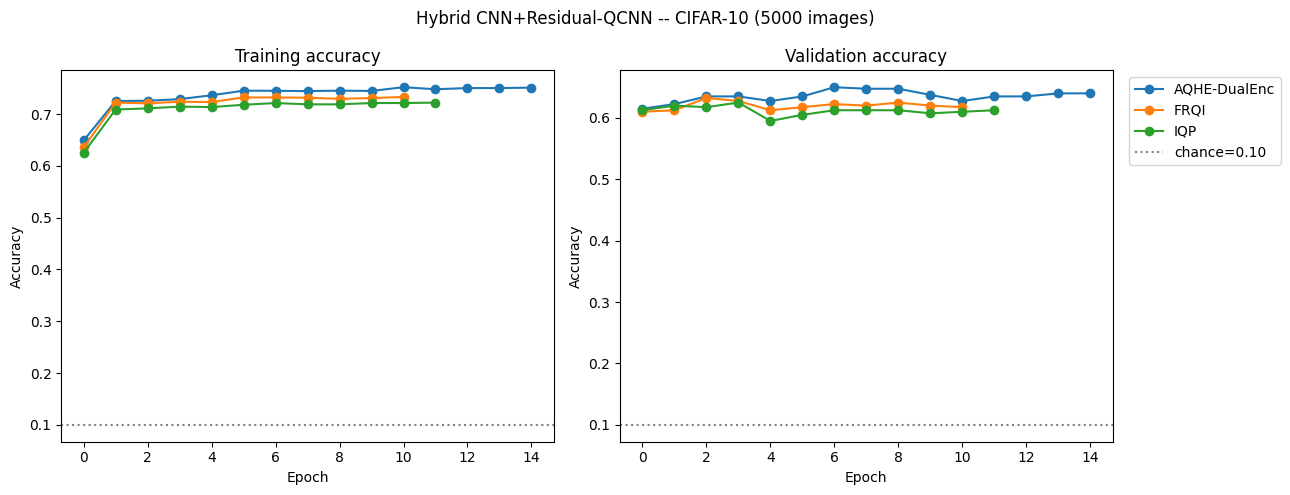

In [25]:
print("=" * 66)
print("CIFAR-10 -- HYBRID CNN+RESIDUAL-QCNN PIPELINE -- SUMMARY")
print("=" * 66)
print(f"\nImages: {len(X_images)} (500/class)  |  CNN embed dim: {CONFIG['CNN_EMBED_DIM']}  "
      f"|  final feature dim: {FEATURE_DIM}  |  register: {CONFIG['DEFAULT_N_QUBITS']} -> "
      f"{CONFIG['N_OUT_QUBITS']} qubits  |  residual reupload scale: {CONFIG['RESIDUAL_REUPLOAD_SCALE']}  "
      f"|  classical skip dim: {CLASSICAL_SKIP_DIM}\n")

print(f"{'Encoding':<18}{'QCNN test acc':>15}")
print("-" * 33)
for name in sorted(qcnn_results, key=qcnn_results.get, reverse=True):
    print(f"{name:<18}{qcnn_results[name]:>15.3f}")

best_encoding = max(qcnn_results, key=qcnn_results.get)
print(f"\nBest embedding: {best_encoding} (acc={qcnn_results[best_encoding]:.3f})")
print(f"Chance-level accuracy: {chance:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, h in histories.items():
    axes[0].plot(h["epoch"], h["train_acc"], marker="o", label=name)
    axes[1].plot(h["epoch"], h["val_acc"], marker="o", label=name)
for ax, ttl in zip(axes, ["Training accuracy", "Validation accuracy"]):
    ax.axhline(chance, color="gray", linestyle=":", label=f"chance={chance:.2f}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.set_title(ttl)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Hybrid CNN+Residual-QCNN -- CIFAR-10 (5000 images)")
plt.tight_layout(); plt.show()


## 13. v4 changelog: fixing the overfitting (train ~96%, val stuck ~55-59%)

**Diagnosis, from the v3 run logs:** train accuracy jumped from ~0 to 85-96% within the *first
1-2 epochs* and then went completely flat, while val accuracy peaked by epoch ~2-3 and then
oscillated/plateaued for the remaining 12+ epochs (occasionally even dropping). That pattern --
near-instant train saturation, flat val -- means the pipeline was landing in a sharp, memorizing
solution almost immediately, not slowly overfitting over many epochs.

**What changed vs. v3, and why:**
1. **QCNN learning rate: 0.05 -> 0.008.** The old LR let Adam jump to a memorizing solution in
   1-2 epochs. A smaller LR forces slower, smoother convergence, giving regularization and
   early stopping (below) room to actually matter.
2. **L2 regularization broadened and strengthened.** Previously only the linear head (`W`, `b`)
   and the FC `StronglyEntanglingLayers` were penalized, at a small `1e-3` coefficient. Now
   `conv_w`/`pool_w` (the actual QCNN convolution/pooling weights) are penalized too, at a
   separate, smaller coefficient (`L2_LAMBDA_CIRCUIT=0.002`) so the circuit isn't pushed toward
   doing nothing, while the head + FC layers get a larger `L2_LAMBDA=0.02`.
3. **Early stopping (`EARLY_STOP_PATIENCE=4`).** Val accuracy was flat from epoch ~3 onward in
   every v3 run; there was nothing to gain from the remaining epochs, and much to lose in
   wall-clock time (~4.8 hours per encoding). Training now stops once val hasn't improved in 4
   epochs, and the best-val checkpoint (already implemented in v3) is restored.
4. **`FC_LAYERS`: 3 -> 2.** One fewer `StronglyEntanglingLayers` layer in the quantum classifier
   head reduces trainable capacity relative to the 3600 training samples.
5. **Shrinkage LDA (`LDA_SHRINKAGE=True`, `solver="lsqr", shrinkage="auto"`).** Vanilla LDA
   fits an unregularized class-covariance estimate from only ~3600 samples across 10 classes,
   and because LDA is *explicitly optimized to separate the training classes*, that noise gets
   baked into directions that separate train particularly well without generalizing equally to
   val/test. Shrinkage (Ledoit-Wolf) regularizes the covariance estimate -- standard practice
   for LDA when samples are limited relative to classes/dimensions.
6. **CNN feature extractor no longer overfits silently.** It previously had no augmentation, no
   weight decay, and just kept whatever weights existed after the fixed 15th epoch -- but its own
   val accuracy peaked around epoch 9 (0.530) and then wobbled/dropped (down to 0.450 at epoch
   11) before ending at 0.527. Since every downstream stage (PCA/LDA/QCNN) inherits the CNN
   embedding's quality, an overfit or under-selected extractor caps everything after it. Fixed by
   adding: random-crop + horizontal-flip augmentation (`USE_CNN_AUGMENTATION`), Adam weight decay
   (`CNN_WEIGHT_DECAY=5e-4`), dropout before the final FC layer (`CNN_DROPOUT=0.3`), best-val
   checkpointing (mirroring the pattern already used for the QCNN), and early stopping
   (`CNN_EARLY_STOP_PATIENCE=6`).

**How to verify the fix worked when you re-run this notebook:**
- Train accuracy should rise more gradually instead of jumping to 90%+ in epoch 1-2.
- The train/val gap at the end of training should be much smaller than v3's ~35-40 points.
- Val accuracy should show a visible upward trend for several epochs, not an immediate
  flatline, before early stopping kicks in.
- If val accuracy is still much lower than train after this, the next lever to pull is **more
  training data** or a **stronger classical CNN extractor** (Sec. 4's frozen `resnet18`
  suggestion) -- at some point 3600 images for a from-scratch CNN + PCA/LDA + QCNN stack is
  genuinely capacity-limited, and no amount of regularization substitutes for more data.

**If accuracy is still capacity-limited after this, in priority order:**
- Try the frozen pretrained `resnet18` embedding (Sec. 4 comment) instead of training from
  scratch on only 4000 images -- this is likely the single biggest remaining lever.
- Sweep `RESIDUAL_REUPLOAD_SCALE` in {0, 0.15, 0.3, 0.5} and `CLASSICAL_SKIP_DIM` in
  {0, 4, 8, 16} to isolate how much each residual path is actually contributing -- report both
  ablations in the BTP writeup.
- If simulation time is still a bottleneck, reduce `N_ENCODINGS_TO_RUN` to your top 2-3
  candidates (found on a smaller subsample first), or move to a hardware-efficient ansatz with
  fewer entangling gates per layer.


## 14. v5 changelog: fixing the "stops learning after 2 epochs" plateau

**Diagnosis, from the v4 run logs:** the overfitting fix worked -- train (~65-68%) and val
(~59-61%) are now close together, a healthy generalization gap. But loss/accuracy went
completely flat after epoch 2-3 in every encoding and never moved again for the remaining
6-10 epochs before early stopping triggered. That's not premature early stopping (each run
genuinely sat flat for many consecutive epochs before stopping) -- it's the optimizer
converging to a low-capacity equilibrium and staying there. v4 over-corrected: LR=0.008 combined
with L2=0.02/0.002 was too conservative to keep escaping shallow local minima, and the quantum
FC layer was initialized so close to identity (`0.01 * randn`) that it started with almost no
influence and correspondingly tiny gradients.

**What changed vs. v4, and why:**
1. **LR: 0.008 -> 0.02**, restoring a middle ground between v3's 0.05 (which overfit instantly)
   and v4's 0.008 (which stalled). On its own this alone would risk sliding back toward v3's
   behavior -- which is exactly what the next change prevents.
2. **Reduce-LR-on-plateau (`LR_DECAY_FACTOR=0.5`, `LR_DECAY_PATIENCE=2`).** This is the actual
   fix for "stops learning after 2 epochs": instead of jumping straight from "no improvement" to
   "give up," the optimizer's step size is now halved after 2 stagnant epochs and training
   continues at the smaller step size -- often enough on its own to escape a shallow plateau.
   Early stopping (`EARLY_STOP_PATIENCE=8`) is now measured in epochs *since the last LR decay*,
   not epochs since the last val improvement, so a run only truly stops after it's had a real
   chance to recover at a smaller step size and still failed to.
3. **L2 lowered (`L2_LAMBDA`: 0.02 -> 0.006, `L2_LAMBDA_CIRCUIT`: 0.002 -> 0.0005).** The v4
   coefficients, combined with the low LR, were strong enough to pin weights near their L2
   equilibrium almost immediately, leaving little room for the cross-entropy gradient to keep
   improving the fit.
4. **Quantum FC-layer init: 0.01 -> 0.05.** Starting the entangling layer this close to identity
   meant it began with very little influence on the output and correspondingly tiny gradients --
   it was barely participating in learning. A larger initial spread gives it room to actually move.
5. **EPOCHS ceiling: 15 -> 30.** With decay-on-plateau instead of a single fixed LR, training can
   legitimately keep making slow progress well past epoch 15; the old ceiling would have cut off
   a run right as a decayed-LR phase started paying off.

**How to verify the fix worked when you re-run this notebook:** the per-epoch log now prints the
current `lr` alongside loss/accuracy. You should see 1-3 "decaying lr to ..." messages per
encoding, each followed by a further (even if small) improvement in val accuracy before the next
plateau -- rather than one flat line from epoch 2 onward. If you *still* see zero improvement even
immediately after an LR decay, that's a stronger signal the pipeline has hit a genuine capacity
ceiling (not an optimization issue), and the next lever is architecture capacity (e.g. `FC_LAYERS`
back to 3, or `N_OUT_QUBITS` to 5-6) or a better CNN extractor (Sec. 4's frozen `resnet18` option),
not further LR/schedule tuning.


## 15. v6: Feature Pyramid + Anchor-Style Multi-Scale Quantum Fusion (FPN-QCNN)

**Motivation.** Every version so far (v2-v5) collapses the CNN backbone down to a single
128-d penultimate embedding (Sec. 4) before PCA/LDA/quantum encoding. That embedding is taken
*after* the last residual block (`layer3`, 8x8 spatial, most downsampled) -- it's dominated by
global/semantic content and has already thrown away the fine spatial detail present in
`layer1`/`layer2`. Since accuracy plateaued at the same ceiling across v3-v5 despite fixing
optimization issues (overfitting, then stalling), the next lever isn't optimization -- it's
**what information reaches the quantum circuit at all**. This section tests whether feeding the
QCNN multi-scale features (local edges/texture *and* mid-level parts *and* global/semantic
content, simultaneously) breaks the ceiling.

### 15.1 Mapping classical FPN + anchors onto this pipeline

**Classical Feature Pyramid Network (Lin et al., 2017):** a backbone produces feature maps
`C1, C2, C3` at decreasing spatial resolution / increasing semantic depth. A top-down pathway
merges them: `P3 = Conv1x1(C3)`, `P2 = Conv1x1(C2) + Upsample(P3)`, `P1 = Conv1x1(C1) +
Upsample(P2)`. Each `P_i` now carries both the fine spatial resolution of its own level *and* the
semantic content of every deeper level. **Anchors** are then reference boxes tiled at fixed
locations on each `P_i`, giving the detector multiple scale/aspect priors per spatial position.

**What transfers directly to this (classification, not detection) pipeline:**
- The **top-down pathway with lateral 1x1 convs** transfers exactly -- implemented below
  unchanged (`FPNSmallResNet`).
- **Anchors** don't have a literal meaning here (no bounding-box regression target exists in a
  10-way classifier). What we borrow is the *spirit* of anchors: fixed-location multi-region
  sampling instead of one global-average-pooled vector. Concretely, each `P_i` is
  adaptive-avg-pooled to a small fixed grid (`ANCHOR_GRID x ANCHOR_GRID`, e.g. 2x2) rather than
  to a single scalar per channel -- these grid cells are the "anchors": fixed spatial reference
  regions whose pooled descriptors are concatenated into one per-level feature vector. This is
  honest labeling: it is anchor-*style* multi-region sampling, not object-detection anchors.

**Adapting the fused pyramid into the QCNN (the actual novel part):**
- Each pyramid level's anchor-pooled vector gets its **own PCA/LDA reduction** and its **own
  qubit register** (`QUBITS_PER_LEVEL` qubits), instead of being flattened into one PCA/LDA
  vector like Sec. 5. So the joint state going into the circuit is
  `|psi_fine> ⊗ |psi_mid> ⊗ |psi_global>` on disjoint wire subsystems -- local, mid, and global
  information are encoded in parallel, not averaged away by a single deep GAP.
- Each register is compressed by its own small QCNN conv/pool stack (reusing `qcnn_stack` from
  Sec. 8 unchanged) down to **one surviving qubit per level**.
- A **cross-level entangling "fusion" ring** (`CRZ`+`CRX` between consecutive surviving qubits)
  is the quantum stand-in for FPN's top-down lateral *addition*. This is the important
  mathematical caveat: quantum registers don't literally "add" the way `P2 = lat(C2) +
  Upsample(P3)` adds real-valued tensors. Two independently-encoded qubits start in a **product
  state** (no shared information); entangling gates move the joint state off the product manifold,
  correlating the levels so that a measurement on one qubit's expectation value becomes dependent
  on the other levels' encoded data. That's a genuinely different (and strictly more expressive,
  in the sense of accessing entangled feature correlations classical addition cannot) fusion
  mechanism than FPN's addition -- but it is *not* the same operation, and doesn't have a
  guaranteed-safe identity/no-op like `+0` does classically; the bridge weights start small
  (`0.1 * randn`) but need to be learned, they don't default to "ignore other levels."
- The shared `StronglyEntanglingLayers` classifier head then reads out the fused, multi-scale
  state, exactly as Sec. 9's FC layer read out the single-scale one.

**Practical feasibility -- qubit budget.** `DEFAULT_N_QUBITS=8` was the existing simulator
budget. With 3 levels this section uses `QUBITS_PER_LEVEL=2` -> 6 total register qubits, leaving
headroom under 8 for the fusion + FC layers to act on the 3 surviving qubits post-pooling (well
within budget). Setting `QUBITS_PER_LEVEL=3` (9 total) would exceed the previous per-circuit
qubit count used elsewhere in this notebook -- the code below supports it, but it's slower to
simulate and is left as a config knob, not the default.

**Practical feasibility -- classical side.** The backbone, lateral convs, and anchor-grid pooling
are all implemented with standard `torch` ops (`Conv2d`, `interpolate`, `adaptive_avg_pool2d`);
gradients flow through the whole pyramid exactly like a normal FPN, verified below.

**What this does *not* test:** this section still trains one `HybridQCNN`-style linear readout
on top of concatenated quantum features -- it isn't a full multi-scale *detector*. It is a
controlled test of "does giving the QCNN simultaneous access to local + global scales, via
separate registers plus an entangling fusion bridge, beat single-scale v5" -- report both numbers.


In [26]:
FPN_CONFIG = dict(
    FPN_CHANNELS            = 32,      # unified lateral channel width across all pyramid levels
    ANCHOR_GRID             = 2,       # 2x2 anchor grid per level (fixed-region pooling, see 15.1)
    FPN_EPOCHS              = 25,
    FPN_BATCH_SIZE          = 64,
    FPN_LR                  = 1e-3,
    FPN_WEIGHT_DECAY        = 5e-4,
    FPN_EARLY_STOP_PATIENCE = 6,

    # v6.1: bumped 2 -> 3. The first run showed only out_dim=QUBITS_PER_LEVEL survives LDA per
    # level (see preprocess_level), so 2 qubits/level meant just 2 discriminative dims/level =
    # 6 total reaching the circuit -- *less* than the single-scale baseline's 8 (PCA16->LDA8).
    # "Multi-scale" was actually starving the circuit of information. 3 qubits/level = 9 total
    # dims, now exceeding the baseline. See Sec. 15.7 for the full diagnosis.
    QUBITS_PER_LEVEL          = 3,
    N_LEVELS                  = 3,      # fine (C1) / mid (C2) / global (C3)
    FPN_ENCODING               = "Pi4Angle",   # reuses one of the 10 encodings from Sec. 7, per-register
    FPN_FC_LAYERS              = 2,
    FPN_CLASSICAL_SKIP_DIM     = 8,
    FPN_BRIDGE_ROUNDS          = 2,     # v6.1: 2 rounds of cross-level entangling (was 1, see 15.7)

    FPN_EPOCHS_Q               = 20,    # v6.1: 30 -> 20 per request
    FPN_LR_Q                   = 0.02,
    FPN_L2_LAMBDA              = 0.006,
    FPN_L2_LAMBDA_CIRCUIT      = 0.0005,
    FPN_EARLY_STOP_PATIENCE_Q  = 8,

    # v6.1: explore-before-shrink LR schedule (see train_fpn_qcnn in 15.5). On a non-improving
    # epoch, the LR is *increased* (to try to escape a plateau) for up to
    # FPN_LR_INCREASE_MAX_EPOCHS consecutive non-improving epochs since the last best; only once
    # that budget is exhausted without a new best does it fall back to shrinking, as before.
    FPN_LR_INCREASE_FACTOR     = 1.4,
    FPN_LR_INCREASE_MAX_EPOCHS = 6,
    FPN_LR_MAX                 = 0.1,   # safety cap so the explore phase can't diverge
    FPN_LR_DECAY_FACTOR        = 0.5,   # used only after the explore budget is exhausted
)

N_QUBITS_TOTAL_FPN = FPN_CONFIG["QUBITS_PER_LEVEL"] * FPN_CONFIG["N_LEVELS"]
print(f"FPN-QCNN qubit budget: {FPN_CONFIG['QUBITS_PER_LEVEL']} qubits/level x "
      f"{FPN_CONFIG['N_LEVELS']} levels = {N_QUBITS_TOTAL_FPN} total register qubits "
      f"(single-scale baseline used {CONFIG['DEFAULT_N_QUBITS']})")
FPN_CONFIG


FPN-QCNN qubit budget: 3 qubits/level x 3 levels = 9 total register qubits (single-scale baseline used 8)


{'FPN_CHANNELS': 32,
 'ANCHOR_GRID': 2,
 'FPN_EPOCHS': 25,
 'FPN_BATCH_SIZE': 64,
 'FPN_LR': 0.001,
 'FPN_WEIGHT_DECAY': 0.0005,
 'FPN_EARLY_STOP_PATIENCE': 6,
 'QUBITS_PER_LEVEL': 3,
 'N_LEVELS': 3,
 'FPN_ENCODING': 'Pi4Angle',
 'FPN_FC_LAYERS': 2,
 'FPN_CLASSICAL_SKIP_DIM': 8,
 'FPN_BRIDGE_ROUNDS': 2,
 'FPN_EPOCHS_Q': 20,
 'FPN_LR_Q': 0.02,
 'FPN_L2_LAMBDA': 0.006,
 'FPN_L2_LAMBDA_CIRCUIT': 0.0005,
 'FPN_EARLY_STOP_PATIENCE_Q': 8,
 'FPN_LR_INCREASE_FACTOR': 1.4,
 'FPN_LR_INCREASE_MAX_EPOCHS': 6,
 'FPN_LR_MAX': 0.1,
 'FPN_LR_DECAY_FACTOR': 0.5}

### 15.2 Classical FPN backbone: top-down pathway + anchor-grid pooling

Reuses `ResidualBlock` from Sec. 4 unchanged. `FPNSmallResNet` exposes `C1`/`C2`/`C3` (instead of
collapsing straight to a single 128-d embedding), builds the top-down FPN pathway with lateral
1x1 convs, and returns three anchor-pooled vectors -- one per pyramid level -- when
`return_anchors=True`. The classification head (used only to *train* the backbone, same role as
`SmallResNet.fc` in Sec. 4) sits on the global/semantic level `P3`.


In [27]:
class FPNSmallResNet(nn.Module):
    """Same stem/backbone as SmallResNet (Sec. 4), but exposes C1/C2/C3 and builds a
    top-down FPN pathway + anchor-grid pooling per level instead of collapsing straight
    to one 128-d embedding. See Sec. 15.1 for why."""
    def __init__(self, num_classes=10, fpn_ch=32, anchor_grid=2, dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU())
        self.layer1 = ResidualBlock(32, 32, stride=1)    # C1: 32x32 -- local edges/texture
        self.layer2 = ResidualBlock(32, 64, stride=2)    # C2: 16x16 -- mid-level parts
        self.layer3 = ResidualBlock(64, 128, stride=2)   # C3: 8x8  -- global/semantic
        self.lat1 = nn.Conv2d(32, fpn_ch, 1)
        self.lat2 = nn.Conv2d(64, fpn_ch, 1)
        self.lat3 = nn.Conv2d(128, fpn_ch, 1)
        self.anchor_grid = anchor_grid
        self.dropout = nn.Dropout(dropout)
        # classification head trained on the global/semantic level -- same role as
        # SmallResNet.fc in Sec. 4, just relocated onto P3 instead of the raw pooled backbone.
        self.fc = nn.Linear(fpn_ch, num_classes)

    def forward(self, x, return_anchors=False):
        c1 = self.layer1(self.stem(x))
        c2 = self.layer2(c1)
        c3 = self.layer3(c2)
        # top-down pathway: P3 = lat3(C3); P2 = lat2(C2) + Upsample(P3); P1 = lat1(C1) + Upsample(P2)
        p3 = self.lat3(c3)
        p2 = self.lat2(c2) + F.interpolate(p3, size=c2.shape[-2:], mode="nearest")
        p1 = self.lat1(c1) + F.interpolate(p2, size=c1.shape[-2:], mode="nearest")
        if return_anchors:
            g = self.anchor_grid
            a1 = F.adaptive_avg_pool2d(p1, g).flatten(1)   # local/fine anchor summary
            a2 = F.adaptive_avg_pool2d(p2, g).flatten(1)   # mid anchor summary
            a3 = F.adaptive_avg_pool2d(p3, g).flatten(1)   # global/semantic anchor summary
            return a1, a2, a3
        pooled = F.adaptive_avg_pool2d(p3, 1).flatten(1)
        return self.fc(self.dropout(pooled))


def train_fpn_extractor(X_train_img, y_train, X_val_img, y_val, config, fpn_config, device=DEVICE):
    model = FPNSmallResNet(num_classes=config["NUM_CLASSES"], fpn_ch=fpn_config["FPN_CHANNELS"],
                            anchor_grid=fpn_config["ANCHOR_GRID"],
                            dropout=config.get("CNN_DROPOUT", 0.3)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=fpn_config["FPN_LR"],
                            weight_decay=fpn_config["FPN_WEIGHT_DECAY"])
    Xtr = to_tensor_batch(X_train_img).to(device)
    ytr = torch.from_numpy(y_train).long().to(device)
    Xva = to_tensor_batch(X_val_img).to(device)
    yva = torch.from_numpy(y_val).long().to(device)

    n = len(Xtr)
    best_val_acc, best_state, epochs_no_improve = -1.0, None, 0
    for epoch in range(fpn_config["FPN_EPOCHS"]):
        model.train()
        perm = torch.randperm(n)
        epoch_loss = 0.0
        for start in range(0, n, fpn_config["FPN_BATCH_SIZE"]):
            idx = perm[start:start + fpn_config["FPN_BATCH_SIZE"]]
            xb, yb = Xtr[idx], ytr[idx]
            xb = augment_batch(xb)          # reuse Sec. 4's augmentation
            opt.zero_grad()
            loss = F.cross_entropy(model(xb), yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(idx)
        model.eval()
        with torch.no_grad():
            val_acc = (model(Xva).argmax(1) == yva).float().mean().item()

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        marker = "  <-- best so far" if is_best else ""
        print(f"  [FPN extractor] epoch {epoch+1:2d}/{fpn_config['FPN_EPOCHS']} "
              f"loss={epoch_loss/n:.4f}  val_acc={val_acc:.3f}{marker}")

        if fpn_config["FPN_EARLY_STOP_PATIENCE"] and epochs_no_improve >= fpn_config["FPN_EARLY_STOP_PATIENCE"]:
            print(f"  [FPN extractor] early stopping (no val improvement in "
                  f"{fpn_config['FPN_EARLY_STOP_PATIENCE']} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"  [FPN extractor] restored best checkpoint: val_acc={best_val_acc:.3f}")
    return model


def extract_fpn_anchors(model, X_img, device=DEVICE, batch_size=256):
    model.eval()
    a1s, a2s, a3s = [], [], []
    with torch.no_grad():
        for start in range(0, len(X_img), batch_size):
            xb = to_tensor_batch(X_img[start:start + batch_size]).to(device)
            a1, a2, a3 = model(xb, return_anchors=True)
            a1s.append(a1.cpu().numpy()); a2s.append(a2.cpu().numpy()); a3s.append(a3.cpu().numpy())
    return np.concatenate(a1s), np.concatenate(a2s), np.concatenate(a3s)


fpn_model = train_fpn_extractor(X_train_img, y_train, X_val_img, y_val, CONFIG, FPN_CONFIG)
a1_train, a2_train, a3_train = extract_fpn_anchors(fpn_model, X_train_img)
a1_val, a2_val, a3_val = extract_fpn_anchors(fpn_model, X_val_img)
a1_test, a2_test, a3_test = extract_fpn_anchors(fpn_model, X_test_img)
print("Anchor vector shapes (fine / mid / global):", a1_train.shape, a2_train.shape, a3_train.shape)


  [FPN extractor] epoch  1/25 loss=2.0125  val_acc=0.308  <-- best so far
  [FPN extractor] epoch  2/25 loss=1.7715  val_acc=0.355  <-- best so far
  [FPN extractor] epoch  3/25 loss=1.6450  val_acc=0.367  <-- best so far
  [FPN extractor] epoch  4/25 loss=1.5432  val_acc=0.392  <-- best so far
  [FPN extractor] epoch  5/25 loss=1.4828  val_acc=0.430  <-- best so far
  [FPN extractor] epoch  6/25 loss=1.4259  val_acc=0.410
  [FPN extractor] epoch  7/25 loss=1.3859  val_acc=0.452  <-- best so far
  [FPN extractor] epoch  8/25 loss=1.3339  val_acc=0.442
  [FPN extractor] epoch  9/25 loss=1.2872  val_acc=0.498  <-- best so far
  [FPN extractor] epoch 10/25 loss=1.2224  val_acc=0.472
  [FPN extractor] epoch 11/25 loss=1.2117  val_acc=0.468
  [FPN extractor] epoch 12/25 loss=1.1556  val_acc=0.492
  [FPN extractor] epoch 13/25 loss=1.1460  val_acc=0.535  <-- best so far
  [FPN extractor] epoch 14/25 loss=1.1218  val_acc=0.580  <-- best so far
  [FPN extractor] epoch 15/25 loss=1.0891  val_ac

### 15.3 Per-level dimensionality reduction

Each pyramid level gets its own `StandardScaler -> PCA -> shrinkage-LDA -> MinMax(0, pi)` chain
(same recipe as Sec. 5, just applied three times independently instead of once), reduced down to
`QUBITS_PER_LEVEL` dimensions each -- exactly enough to fill that level's quantum register. The
classical skip connection (Sec. 9's role) now comes from the **global/semantic anchor vector**
`a3`, which is the closest analogue of the old 128-d embedding's dominant content.


In [28]:
def preprocess_level(a_train, a_val, a_test, y_train, out_dim, config):
    ss = StandardScaler()
    Ztr = ss.fit_transform(a_train)
    Zva = ss.transform(a_val)
    Zte = ss.transform(a_test)

    pca_dim = max(out_dim, min(out_dim * 2, Ztr.shape[1]))
    pca = PCA(n_components=pca_dim, random_state=config["RANDOM_SEED"])
    Ptr = pca.fit_transform(Ztr)
    Pva = pca.transform(Zva)
    Pte = pca.transform(Zte)

    lda_dim = min(out_dim, config["NUM_CLASSES"] - 1, pca_dim)
    lda = LDA(n_components=lda_dim, solver="eigen", shrinkage="auto")   # same fix as Sec. 5
    Ftr = lda.fit_transform(Ptr, y_train)
    Fva = lda.transform(Pva)
    Fte = lda.transform(Pte)

    mm = MinMaxScaler(feature_range=(0, np.pi))
    return mm.fit_transform(Ftr), mm.transform(Fva), mm.transform(Fte)


QPL = FPN_CONFIG["QUBITS_PER_LEVEL"]
X1_train, X1_val, X1_test = preprocess_level(a1_train, a1_val, a1_test, y_train, QPL, CONFIG)  # fine
X2_train, X2_val, X2_test = preprocess_level(a2_train, a2_val, a2_test, y_train, QPL, CONFIG)  # mid
X3_train, X3_val, X3_test = preprocess_level(a3_train, a3_val, a3_test, y_train, QPL, CONFIG)  # global

print("Per-level reduced feature shapes:", X1_train.shape, X2_train.shape, X3_train.shape)
print(f"Total quantum-encoded dims: {X1_train.shape[1] + X2_train.shape[1] + X3_train.shape[1]} "
      f"(single-scale baseline fed the circuit 8 dims total -- see Sec. 15.7)")

# v6.1: classical skip now pools a small slice from EACH level (fine + mid + global) instead of
# only the global anchor vector -- the skip connection was silently single-scale before, which
# worked against the whole point of this section. Same total width as before (FPN_CLASSICAL_SKIP_DIM).
_skip_total = FPN_CONFIG["FPN_CLASSICAL_SKIP_DIM"]
_per_level_skip = max(1, _skip_total // 3)

def _slice_stats(a_train, a_val, a_test, dim):
    ss = StandardScaler().fit(a_train[:, :dim])
    return ss.transform(a_train[:, :dim]), ss.transform(a_val[:, :dim]), ss.transform(a_test[:, :dim])

_s1_tr, _s1_va, _s1_te = _slice_stats(a1_train, a1_val, a1_test, _per_level_skip)
_s2_tr, _s2_va, _s2_te = _slice_stats(a2_train, a2_val, a2_test, _per_level_skip)
_s3_tr, _s3_va, _s3_te = _slice_stats(a3_train, a3_val, a3_test, _skip_total - 2 * _per_level_skip)

fpn_skip_train = np.concatenate([_s1_tr, _s2_tr, _s3_tr], axis=1)
fpn_skip_val = np.concatenate([_s1_va, _s2_va, _s3_va], axis=1)
fpn_skip_test = np.concatenate([_s1_te, _s2_te, _s3_te], axis=1)
print("Classical skip shape (multi-scale now):", fpn_skip_train.shape)


Per-level reduced feature shapes: (3600, 3) (3600, 3) (3600, 3)
Total quantum-encoded dims: 9 (single-scale baseline fed the circuit 8 dims total -- see Sec. 15.7)
Classical skip shape (multi-scale now): (3600, 8)


### 15.4 Multi-register quantum circuit: per-level encoding + cross-level entangling fusion bridge

Reuses `conv_block`/`pool_block`/`qcnn_stack`/`n_conv_pool_layers` from Sec. 8 completely
unchanged -- the only new piece is *how many registers* exist and *how they're bridged*. Each
pyramid level is encoded onto its own `QUBITS_PER_LEVEL`-qubit register with the same encoding
function (`FPN_CONFIG["FPN_ENCODING"]`, any of the 10 from Sec. 7), compressed by its own
conv/pool stack down to one surviving qubit, then the three surviving qubits (one per scale) are
entangled in a ring (`CRZ`+`CRX`) before the shared `StronglyEntanglingLayers` head -- see 15.1
for why this ring is the quantum stand-in for FPN's top-down addition, and how it differs.


In [29]:
def build_fpn_qcnn_circuit(encoding_fn, qubits_per_level, n_levels, fc_layers, multi_basis, bridge_rounds=1):
    n_qubits = qubits_per_level * n_levels
    level_wires = [list(range(l * qubits_per_level, (l + 1) * qubits_per_level)) for l in range(n_levels)]
    dev = qml.device(CONFIG["QUANTUM_DEVICE"], wires=n_qubits)
    diff_method = CONFIG.get("DIFF_METHOD", "adjoint") if CONFIG["QUANTUM_DEVICE"] == "lightning.qubit" else "backprop"

    @qml.qnode(dev, diff_method=diff_method)
    def circuit(x_levels, level_conv_w, level_pool_w, bridge_w, fc_w):
        # 1) encode each pyramid level onto its own register -- local/fine, mid, and
        #    global/semantic live in separate qubit subsystems instead of one flattened vector
        for l in range(n_levels):
            encoding_fn(x_levels[l], level_wires[l])

        # 2) per-level conv/pool -- compress each register down to 1 surviving qubit
        #    (reuses qcnn_stack from Sec. 8 unchanged, including its residual re-upload)
        survivors = []
        for l in range(n_levels):
            w = level_wires[l]
            remaining = qcnn_stack(x_levels[l], w, level_conv_w[l], level_pool_w[l], n_out=1,
                                    depth_per_layer=CONFIG["CONV_DEPTH"],
                                    reupload_scale=CONFIG["RESIDUAL_REUPLOAD_SCALE"])
            survivors.extend(remaining)

        # 3) cross-level fusion bridge -- entangling ring across the surviving qubits, the
        #    quantum analogue of FPN's top-down lateral "addition" between scales (see 15.1
        #    for why this is a related-but-not-identical operation to classical addition).
        #    v6.1: run this ring `bridge_rounds` times (each with its own weights) instead of
        #    once -- a single CRZ+CRX pass only lets adjacent-in-the-ring survivors interact
        #    once, which is a very shallow fusion compared to the baseline's full
        #    StronglyEntanglingLayers over all its register qubits (see 15.7).
        for r in range(bridge_rounds):
            for i in range(n_levels):
                a, b = survivors[i], survivors[(i + 1) % n_levels]
                qml.CRZ(bridge_w[r, i, 0], wires=[a, b])
                qml.CRX(bridge_w[r, i, 1], wires=[a, b])

        # 4) shared classifier head over the fused, multi-scale survivors
        qml.StronglyEntanglingLayers(fc_w, wires=survivors)
        outs = [qml.expval(qml.PauliZ(w)) for w in survivors]
        if multi_basis:
            outs += [qml.expval(qml.PauliX(w)) for w in survivors]
            outs += [qml.expval(qml.PauliY(w)) for w in survivors]
        return tuple(outs)

    feat_dim = n_levels * (3 if multi_basis else 1)
    return circuit, level_wires, feat_dim


def init_fpn_qcnn_weights(qubits_per_level, n_levels, fc_layers, bridge_rounds=1, seed=0):
    rng = np.random.default_rng(seed)
    n_layers = n_conv_pool_layers(qubits_per_level, 1)   # each level compresses to 1 surviving qubit
    level_conv_w = pnp.array(0.1 * rng.standard_normal((n_levels, n_layers, CONFIG["CONV_DEPTH"], CONV_PARAMS)),
                              requires_grad=True)
    level_pool_w = pnp.array(0.1 * rng.standard_normal((n_levels, n_layers, POOL_PARAMS)), requires_grad=True)
    bridge_w = pnp.array(0.1 * rng.standard_normal((bridge_rounds, n_levels, 2)), requires_grad=True)
    fc_shape = qml.StronglyEntanglingLayers.shape(n_layers=fc_layers, n_wires=n_levels)
    fc_w = pnp.array(0.05 * rng.standard_normal(fc_shape), requires_grad=True)
    return level_conv_w, level_pool_w, bridge_w, fc_w


class FPN_HybridQCNN:
    def __init__(self, encoding_name, qubits_per_level, n_levels, classical_skip_dim, seed=42):
        self.encoding_name = encoding_name
        self.encoding_fn = ENCODINGS[encoding_name]
        self.qubits_per_level = qubits_per_level
        self.n_levels = n_levels
        self.fc_layers = FPN_CONFIG["FPN_FC_LAYERS"]
        self.bridge_rounds = FPN_CONFIG["FPN_BRIDGE_ROUNDS"]
        self.multi_basis = CONFIG["USE_MULTI_BASIS_READOUT"]
        self.classical_skip_dim = classical_skip_dim

        self.circuit, self.level_wires, self.feat_dim = build_fpn_qcnn_circuit(
            self.encoding_fn, qubits_per_level, n_levels, self.fc_layers, self.multi_basis,
            bridge_rounds=self.bridge_rounds)

        self.level_conv_w, self.level_pool_w, self.bridge_w, self.fc_w = init_fpn_qcnn_weights(
            qubits_per_level, n_levels, self.fc_layers, bridge_rounds=self.bridge_rounds, seed=seed)

        rng = np.random.default_rng(seed)
        feat_dim = self.feat_dim + self.classical_skip_dim
        self.W = pnp.array(0.1 * rng.standard_normal((feat_dim, CONFIG["NUM_CLASSES"])), requires_grad=True)
        self.b = pnp.array(np.zeros(CONFIG["NUM_CLASSES"]), requires_grad=True)

    def all_params(self):
        return (self.level_conv_w, self.level_pool_w, self.bridge_w, self.fc_w, self.W, self.b)

    def set_params(self, flat):
        self.level_conv_w, self.level_pool_w, self.bridge_w, self.fc_w, self.W, self.b = flat

    def forward_batch(self, X1, X2, X3, skip_batch, level_conv_w, level_pool_w, bridge_w, fc_w, W, b):
        raw = self.circuit([X1, X2, X3], level_conv_w, level_pool_w, bridge_w, fc_w)
        feats = assemble_features(raw, self.multi_basis, self.n_levels, is_batched=True)
        if self.classical_skip_dim > 0:
            feats = pnp.concatenate([feats, pnp.array(skip_batch)], axis=1)
        return feats @ W + b

    def predict_proba_numpy(self, X1, X2, X3, skip_batch, batch_size=64):
        outs = []
        n = len(X1)
        for start in range(0, n, batch_size):
            sl = slice(start, start + batch_size)
            raw = self.circuit([X1[sl], X2[sl], X3[sl]], self.level_conv_w, self.level_pool_w,
                                self.bridge_w, self.fc_w)
            feats = np.array(assemble_features(raw, self.multi_basis, self.n_levels, True))
            if self.classical_skip_dim > 0:
                feats = np.concatenate([feats, skip_batch[sl]], axis=1)
            logits = feats @ np.array(self.W) + np.array(self.b)
            ex = np.exp(logits - logits.max(axis=1, keepdims=True))
            outs.append(ex / ex.sum(axis=1, keepdims=True))
        return np.concatenate(outs, axis=0)

    def predict(self, X1, X2, X3, skip_batch, batch_size=64):
        return np.argmax(self.predict_proba_numpy(X1, X2, X3, skip_batch, batch_size), axis=1)


print(f"FPN-QCNN circuit uses {FPN_CONFIG['QUBITS_PER_LEVEL'] * FPN_CONFIG['N_LEVELS']} qubits total "
      f"({FPN_CONFIG['N_LEVELS']} registers x {FPN_CONFIG['QUBITS_PER_LEVEL']} qubits each), "
      f"{FPN_CONFIG['FPN_BRIDGE_ROUNDS']} fusion-bridge round(s)")


FPN-QCNN circuit uses 9 qubits total (3 registers x 3 qubits each), 2 fusion-bridge round(s)


### 15.5 Training loop

Same reduce-LR-on-plateau + best-val checkpointing pattern as `train_hybrid_qcnn` (Sec. 10),
adapted for the 6-parameter-group structure (`level_conv_w, level_pool_w, bridge_w, fc_w, W, b`)
instead of the per-chunk filter list used by the single-scale model.


In [30]:
def train_fpn_qcnn(model, X1_train, X2_train, X3_train, skip_train, y_train_onehot,
                    X1_val, X2_val, X3_val, skip_val, y_val,
                    epochs, batch_size, lr, verbose=True,
                    l2_lambda=0.006, l2_lambda_circuit=0.0005, patience=8,
                    lr_increase_factor=1.4, lr_increase_max_epochs=6, lr_max=0.1,
                    lr_decay_factor=0.5):
    """v6.1 schedule: on a non-improving epoch, INCREASE the lr first (try to escape a plateau)
    for up to `lr_increase_max_epochs` consecutive non-improving epochs since the last best.
    Only once that explore budget is exhausted without a new best does it fall back to shrinking
    the lr (old behaviour). Hitting a new best resets the counter, so the next plateau gets a
    fresh explore budget too."""
    opt = qml.AdamOptimizer(stepsize=lr)
    n = len(X1_train)
    rng = np.random.default_rng(0)

    def cost(level_conv_w, level_pool_w, bridge_w, fc_w, W, b, Xb1, Xb2, Xb3, Sb, Yb):
        logits = model.forward_batch(Xb1, Xb2, Xb3, Sb, level_conv_w, level_pool_w, bridge_w, fc_w, W, b)
        ce_loss = softmax_cross_entropy_batch(logits, Yb)
        l2 = pnp.sum(W ** 2) + pnp.sum(b ** 2) + pnp.sum(fc_w ** 2)
        l2_circuit = pnp.sum(level_conv_w ** 2) + pnp.sum(level_pool_w ** 2) + pnp.sum(bridge_w ** 2)
        return ce_loss + l2_lambda * l2 + l2_lambda_circuit * l2_circuit

    params = list(model.all_params())
    history = {"epoch": [], "train_loss": [], "train_acc": [], "val_acc": [], "lr": [], "best_val_acc": None}
    best_val_acc, best_params = -1.0, None
    epochs_no_improve = 0          # resets on every new best -- drives both explore and shrink phases
    epochs_since_best = 0          # never reset except on new best -- drives early stopping

    for epoch in range(epochs):
        perm = rng.permutation(n)
        epoch_loss, n_batches, train_correct, train_seen = 0.0, 0, 0, 0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            Xb1, Xb2, Xb3 = X1_train[idx], X2_train[idx], X3_train[idx]
            Sb, Yb = skip_train[idx], y_train_onehot[idx]
            new_params = opt.step(lambda *p: cost(*p, Xb1=Xb1, Xb2=Xb2, Xb3=Xb3, Sb=Sb, Yb=Yb), *params)
            params = list(new_params)
            batch_loss = float(cost(*params, Xb1=Xb1, Xb2=Xb2, Xb3=Xb3, Sb=Sb, Yb=Yb))
            epoch_loss += batch_loss
            n_batches += 1
            logits = model.forward_batch(Xb1, Xb2, Xb3, Sb, *params)
            preds = np.argmax(np.array(logits), axis=1)
            train_correct += int((preds == y_train[idx]).sum())
            train_seen += len(idx)

        model.set_params(params)
        train_acc = train_correct / max(train_seen, 1)
        val_acc = accuracy_score(y_val, model.predict(X1_val, X2_val, X3_val, skip_val))
        history["epoch"].append(epoch)
        history["train_loss"].append(epoch_loss / max(n_batches, 1))
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(opt.stepsize)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_params = [np.array(p) for p in params]
            epochs_no_improve = 0
            epochs_since_best = 0
        else:
            epochs_no_improve += 1
            epochs_since_best += 1

        marker = "  <-- best so far" if is_best else ""
        if verbose:
            print(f"  [FPN-QCNN] epoch {epoch+1:2d}/{epochs} lr={opt.stepsize:.5f} "
                  f"loss={epoch_loss/max(n_batches,1):.4f} train_acc={train_acc:.3f} "
                  f"val_acc={val_acc:.3f}{marker}")

        if not is_best:
            if epochs_no_improve <= lr_increase_max_epochs:
                new_lr = min(opt.stepsize * lr_increase_factor, lr_max)
                if verbose:
                    print(f"    no improvement ({epochs_no_improve}/{lr_increase_max_epochs} explore "
                          f"epochs) -- increasing lr to {new_lr:.5f}")
                opt.stepsize = new_lr
            else:
                opt.stepsize *= lr_decay_factor
                if verbose:
                    print(f"    explore budget exhausted -- decaying lr to {opt.stepsize:.5f}")

        if patience and epochs_since_best >= patience:
            print(f"  [FPN-QCNN] early stopping (no val improvement in {patience} epochs)")
            break

    if best_params is not None:
        model.set_params(best_params)
    history["best_val_acc"] = best_val_acc
    print(f"  [FPN-QCNN] restored best checkpoint: val_acc={best_val_acc:.3f}")
    return history


### 15.6 Run + compare against the v5 single-scale baseline

Starts with just `FPN_CONFIG["FPN_ENCODING"]` (one encoding) to keep the first run cheap --
6 total register qubits with `depth_per_layer=CONFIG["CONV_DEPTH"]` conv/pool applications per
level is more circuit structure per forward pass than the single-scale model, so wall-clock time
per epoch will be higher even though the qubit count is comparable. Once this runs cleanly, widen
`fpn_encodings_to_run` to a few more entries from `ENCODINGS` for a fuller comparison.


In [31]:
def run_one_fpn_encoding(name):
    print(f"  -> training FPN-QCNN [{name}] ...")
    t0 = time.time()
    model = FPN_HybridQCNN(name, FPN_CONFIG["QUBITS_PER_LEVEL"], FPN_CONFIG["N_LEVELS"],
                            FPN_CONFIG["FPN_CLASSICAL_SKIP_DIM"], seed=CONFIG["RANDOM_SEED"])
    history = train_fpn_qcnn(model, X1_train, X2_train, X3_train, fpn_skip_train, y_train_onehot,
                              X1_val, X2_val, X3_val, fpn_skip_val, y_val,
                              epochs=FPN_CONFIG["FPN_EPOCHS_Q"], batch_size=CONFIG["BATCH_SIZE"],
                              lr=FPN_CONFIG["FPN_LR_Q"], verbose=True,
                              l2_lambda=FPN_CONFIG["FPN_L2_LAMBDA"],
                              l2_lambda_circuit=FPN_CONFIG["FPN_L2_LAMBDA_CIRCUIT"],
                              patience=FPN_CONFIG["FPN_EARLY_STOP_PATIENCE_Q"],
                              lr_increase_factor=FPN_CONFIG["FPN_LR_INCREASE_FACTOR"],
                              lr_increase_max_epochs=FPN_CONFIG["FPN_LR_INCREASE_MAX_EPOCHS"],
                              lr_max=FPN_CONFIG["FPN_LR_MAX"],
                              lr_decay_factor=FPN_CONFIG["FPN_LR_DECAY_FACTOR"])
    test_acc = accuracy_score(y_test, model.predict(X1_test, X2_test, X3_test, fpn_skip_test))
    print(f"     FPN-QCNN [{name}]: test acc = {test_acc:.3f}  ({time.time() - t0:.1f}s)")
    return name, test_acc, history


fpn_encodings_to_run = [FPN_CONFIG["FPN_ENCODING"]]   # widen once this runs cleanly, e.g. add "AQHE-DualEnc", "FRQI"
print("Running FPN-QCNN for:", fpn_encodings_to_run)

t0 = time.time()
fpn_results = [run_one_fpn_encoding(name) for name in fpn_encodings_to_run]
print(f"FPN-QCNN benchmark took {time.time() - t0:.1f}s total")

print("=" * 66)
print("FPN-QCNN (multi-scale) vs v5 single-scale baseline")
print("=" * 66)
for name, acc, _ in fpn_results:
    baseline = qcnn_results.get(name) if "qcnn_results" in dir() else None
    line = f"{name:16s}  FPN-QCNN test acc = {acc:.3f}"
    if baseline is not None:
        line += f"   |   v5 single-scale baseline = {baseline:.3f}   |   delta = {acc - baseline:+.3f}"
    else:
        line += "   |   (run Sec. 11's benchmark for this encoding to get a baseline to compare against)"
    print(line)


Running FPN-QCNN for: ['Pi4Angle']
  -> training FPN-QCNN [Pi4Angle] ...
  [FPN-QCNN] epoch  1/20 lr=0.02000 loss=1.6058 train_acc=0.433 val_acc=0.480  <-- best so far
  [FPN-QCNN] epoch  2/20 lr=0.02000 loss=1.4432 train_acc=0.501 val_acc=0.482  <-- best so far
  [FPN-QCNN] epoch  3/20 lr=0.02000 loss=1.4299 train_acc=0.502 val_acc=0.487  <-- best so far
  [FPN-QCNN] epoch  4/20 lr=0.02000 loss=1.4200 train_acc=0.517 val_acc=0.470
    no improvement (1/6 explore epochs) -- increasing lr to 0.02800
  [FPN-QCNN] epoch  5/20 lr=0.02800 loss=1.4267 train_acc=0.521 val_acc=0.482
    no improvement (2/6 explore epochs) -- increasing lr to 0.03920
  [FPN-QCNN] epoch  6/20 lr=0.03920 loss=1.4325 train_acc=0.514 val_acc=0.450
    no improvement (3/6 explore epochs) -- increasing lr to 0.05488
  [FPN-QCNN] epoch  7/20 lr=0.05488 loss=1.4428 train_acc=0.515 val_acc=0.453
    no improvement (4/6 explore epochs) -- increasing lr to 0.07683
  [FPN-QCNN] epoch  8/20 lr=0.07683 loss=1.4466 train_acc=

### 15.7 Diagnosis: why v5 (single-scale) beat v6 (FPN-QCNN), and what changed

**The run:** single-scale QCNN's best encoding (AQHE-DualEnc) hit **0.620** test accuracy, with
even its weakest encoding (IQP, 0.580) beating FPN-QCNN's **0.543**. That's the opposite of the
hoped-for result, so it's worth being precise about why before changing anything.

**Root cause 1 -- FPN-QCNN was actually seeing *less* information, not more.**
`preprocess_level`'s LDA step is capped at `out_dim = QUBITS_PER_LEVEL`. With
`QUBITS_PER_LEVEL=2`, every level's LDA could keep only **2** discriminative dimensions, so only
`3 levels x 2 = 6` total dims reached the circuit. The single-scale baseline's `preprocess_hybrid`
reduces the *same* backbone's embedding to PCA(16)->LDA(**8**) -- 8 total dims. So despite the
"multi-scale" framing, FPN-QCNN was strictly information-starved relative to the baseline: 6 dims
vs 8, split across three separately-fit LDAs that each only see one scale's variance rather than
one LDA seeing the joint discriminative structure across all scales at once. **Fix applied:**
`QUBITS_PER_LEVEL` 2 -> 3, giving `3 x 3 = 9` total dims -- now more than baseline's 8.

**Root cause 2 -- the classical skip connection was silently single-scale.** The skip reused only
`a3` (the global/semantic anchor vector), so the "multi-scale" claim didn't even hold for the
classical half of the feature vector feeding the final linear layer. **Fix applied:** the skip
now pools a slice from all three anchor vectors (`a1`, `a2`, `a3`) at the same total width.

**Root cause 3 -- the fusion bridge was too shallow to be a real analogue of FPN's merge.**
One `CRZ`+`CRX` pass across 3 survivors is a single layer of pairwise interaction, versus the
baseline's full `StronglyEntanglingLayers` operating jointly over its 4 register qubits before
any information is thrown away by early per-branch pooling. FPN-QCNN pools each level down to 1
qubit *before* any cross-level interaction happens at all -- so whatever within-level correlations
those 2 (now 3) qubits could have expressed get compressed away before fusion even starts.
**Fix applied:** `FPN_BRIDGE_ROUNDS=2` -- two full entangling rounds instead of one, giving the
surviving qubits more chances to interact before the classifier head.

**Root cause 4 (the one asked about directly) -- the LR schedule likely locked in the plateau
too early.** Both models plateaued in *train* accuracy (baseline ~0.70-0.72, FPN-QCNN ~0.61) with
no sign of overfitting (val tracked train closely, never diverged) -- this is underfitting, i.e.
the optimizer stopped finding improvements, not memorization. FPN-QCNN's log shows lr was cut in
half every single time two epochs passed without a new best, from epoch 6 onward -- by epoch 20
lr was already down to 0.00125, 16x smaller than the start, while train_acc had been flat since
roughly epoch 11. Shrinking lr that aggressively, that early, while train accuracy was still
plateaued (not diverging) removes the step size needed to escape the plateau, likely locking in a
suboptimal solution rather than protecting a good one. **Fix applied:** `train_fpn_qcnn` now
*increases* lr (by `FPN_LR_INCREASE_FACTOR`, capped at `FPN_LR_MAX`) for up to
`FPN_LR_INCREASE_MAX_EPOCHS=6` consecutive non-improving epochs since the last best -- giving the
optimizer room to jump out of a flat region -- and only falls back to the old shrink-by-half
behavior if 6 straight lr increases still don't produce a new best. `FPN_EPOCHS_Q` is now 20
(was 30) per request.

**What to watch for when you re-run:** the explore-then-shrink schedule is a legitimate technique
(related to warm restarts / cyclical LR), but it isn't free -- if train_loss starts *oscillating*
or *increasing* during the explore phase instead of continuing to improve, the lr is being pushed
too high for this loss landscape; lower `FPN_LR_INCREASE_FACTOR` (e.g. 1.4 -> 1.2) or
`FPN_LR_MAX` (0.1 -> 0.05) in that case rather than letting the "6 epochs" run unconditionally.

**Re-run order:** because `QUBITS_PER_LEVEL` and the classical skip changed, re-execute from
Sec. 15.3 (`preprocess_level` cell) through Sec. 15.6 -- Sec. 15.2's anchor vectors (`a1/a2/a3`)
don't need to be re-extracted, only everything downstream of them.

**If this still doesn't beat the baseline:** that would itself be informative -- it would suggest
the ceiling in v3-v5 wasn't purely an information bottleneck (the original hypothesis this
section was built to test, see 15.1), and the more promising direction is probably deepening the
*single-scale* circuit (more qubits, more StronglyEntanglingLayers, before trying multi-scale
fusion again) rather than continuing to add pyramid levels.
